# Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import numpy as np
# from pprint import pprint

In [2]:
def normalize_str(s:str) -> str:
  return " ".join(word.capitalize() for word in s.split("_"))

In [3]:
def get_number_of_instances(df:pd.DataFrame, col:str) -> pd.DataFrame:
  df = (df.groupby(col)
          .agg(number_of_instances = (col, 'count'))
          .sort_values('number_of_instances', ascending=False)
          .reset_index())

  df['percent'] = df['number_of_instances'] / df['number_of_instances'].sum() * 100

  return df

In [4]:
def get_summary_stats(df:pd.DataFrame, col:str) -> pd.DataFrame:
  df_temp = df[col].agg(['mean', lambda x: x.mode()[0], 'median', 'var', 'std'])
  df_temp = pd.concat([df_temp, df[col].quantile([.25, .75])], ignore_index = True)
  df_temp.index = ['mean', 'mode', 'median','var', 'std', 'q1', 'q3']
  return df_temp.reset_index().pivot_table(columns = "index", values = col).reset_index(names = "column_name")

In [5]:
def barplot(df:pd.DataFrame, x:str, y:str = "number_of_instances", n = 10, figsize:tuple[int, int] = (11, 5)) -> None:
  df_plot = df.head(n).copy() if df.shape[0] > n else df.copy()

  df_plot[x] = df_plot[x].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
  )

  plt.subplots(figsize=figsize)

  sns.barplot(
      data=df_plot,
      x=x,
      y=y
  )

  sns.despine()
  plt.title(f"{normalize_str(x)} Counts", loc = "left")

  plt.tight_layout()
  plt.show()

In [6]:
def horizontal_barplot(
    df:pd.DataFrame,
    y:str,
    x:str = "number_of_instances",
    n:int = 10,
    figsize:tuple[int, int] = (11, 5)
    ) -> None:
  df_plot = df.head(n).copy() if df.shape[0] > n else df.copy()

  df_plot[y] = df_plot[y].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
  )

  plt.figure(figsize=figsize)

  sns.barplot(
      data=df_plot,
      y=y,
      x=x
  )

  sns.despine()
  plt.title(f"{normalize_str(col)} Count", loc="left")
  plt.xlabel("Number of Instances")
  plt.ylabel("")
  plt.tight_layout()
  plt.show()

In [7]:
def get_num_nulls(df:pd.DataFrame, col:str) -> int:
  return df[col].isna().sum()

In [8]:
#assumes the dataframe is sorted
def find_num_groups( df: pd.DataFrame, threshold: float = 90, percent_col: str = "percent") -> tuple[int, float]:

    if not 0 < threshold <= 100:
        raise ValueError("Threshold must be between 0 and 100.")

    if threshold == 100:
      return df.shape[0], 100

    cumulative_percent = df[percent_col].cumsum()

    n_groups = (cumulative_percent <= threshold).sum()
    actual_percent = cumulative_percent.iloc[n_groups]

    return n_groups.item() + 1, actual_percent.item()

# Import and Inspection

In [9]:
df = pd.read_parquet('master.parquet')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196737 entries, 0 to 2196736
Data columns (total 27 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   health_service_area             object 
 1   hospital_county                 object 
 2   facility_name                   object 
 3   age_group                       object 
 4   gender                          object 
 5   race                            object 
 6   ethnicity                       object 
 7   length_of_stay                  Int64  
 8   type_of_admission               object 
 9   patient_disposition             object 
 10  discharge_year                  Int64  
 11  ccsr_diagnosis_description      object 
 12  apr_drg_description             object 
 13  apr_mdc_description             object 
 14  apr_severity_of_illness_code    Int64  
 15  apr_severity_of_illness         object 
 16  apr_risk_of_mortality           object 
 17  apr_medical_surgical       

In [11]:
df.isna().sum()

,0
health_service_area,5295
hospital_county,5295
facility_name,0
age_group,0
gender,0
race,0
ethnicity,0
length_of_stay,0
type_of_admission,0
patient_disposition,0


# Characterisitcs (Univariate)

### Health Service Area

The **Health Service Area** variable describes where the hospital is located (broad regiouns: New York City, Long Island, etc.). It is a text field, and it may be blank for records with enhanced de-identification

In [12]:
col = 'health_service_area'
df_temp = get_number_of_instances(df, col)
df_temp

,health_service_area,number_of_instances,percent
0,New York City,996124,45.455184
1,Long Island,359214,16.391673
2,Hudson Valley,243870,11.128289
3,Capital/Adirondacks,143613,6.553356
4,Western NY,142041,6.481623
5,Finger Lakes,140528,6.412581
6,Central NY,138048,6.299414
7,Southern Tier,28004,1.277880


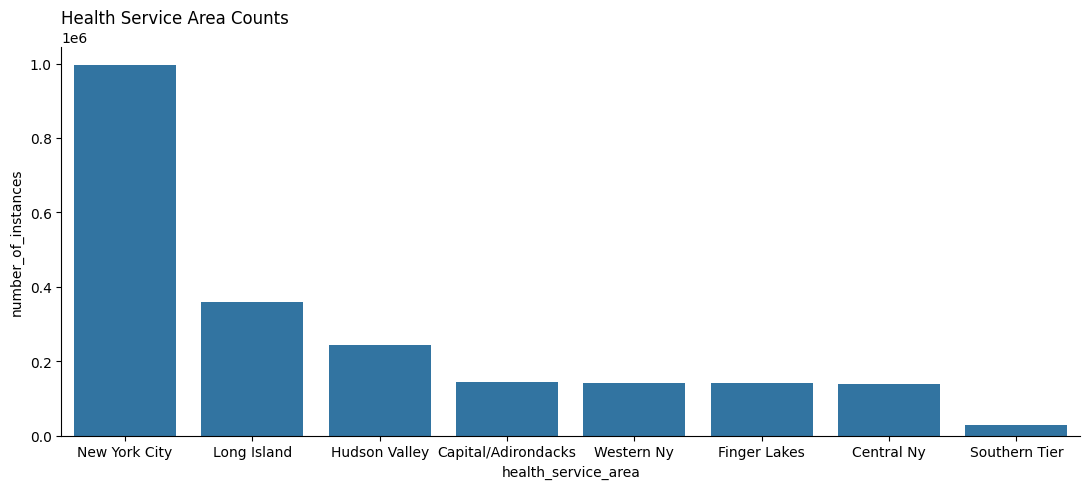

In [13]:
barplot(df_temp, col, 'number_of_instances', figsize=(11, 5))

### Hospital County

The **hospital county** identifies the county where the hospital is located (Kings, Queens, etc.). It is a text field, and it may be blank for records with enhanced de-identification

In [14]:
col = 'hospital_county'
df_temp = get_number_of_instances(df, col).head(10)
df_temp

,hospital_county,number_of_instances,percent
0,New York,389375,17.767981
1,Kings,200536,9.150870
2,Nassau,192048,8.763545
3,Queens,185610,8.469766
4,Suffolk,167166,7.628128
5,Bronx,165312,7.543526
6,Westchester,127036,5.796914
7,Erie,112360,5.127218
8,Monroe,105204,4.800675
9,Onondaga,71592,3.266890


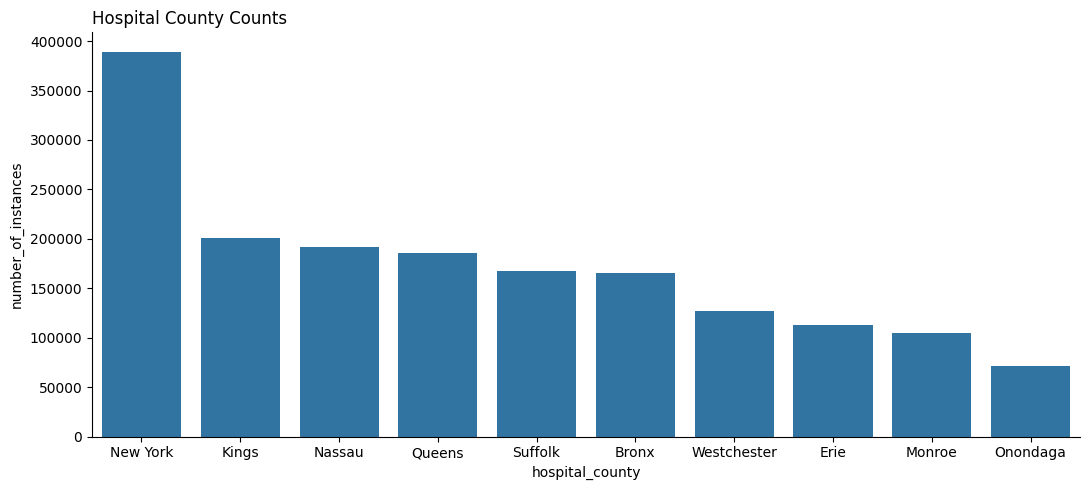

In [15]:
barplot(df_temp, col, 'number_of_instances')

### Facility Name

The **facility name** variable contains the name of the hospital or facility where services were performed. For records with enhanced de-identification, the value appears as “Redacted for Confidentiality.”

In [16]:
col = 'facility_name'
df_temp = get_number_of_instances(df, col) #.head(20)
n_groups = find_num_groups(df_temp, 80)[0]
n_groups

82

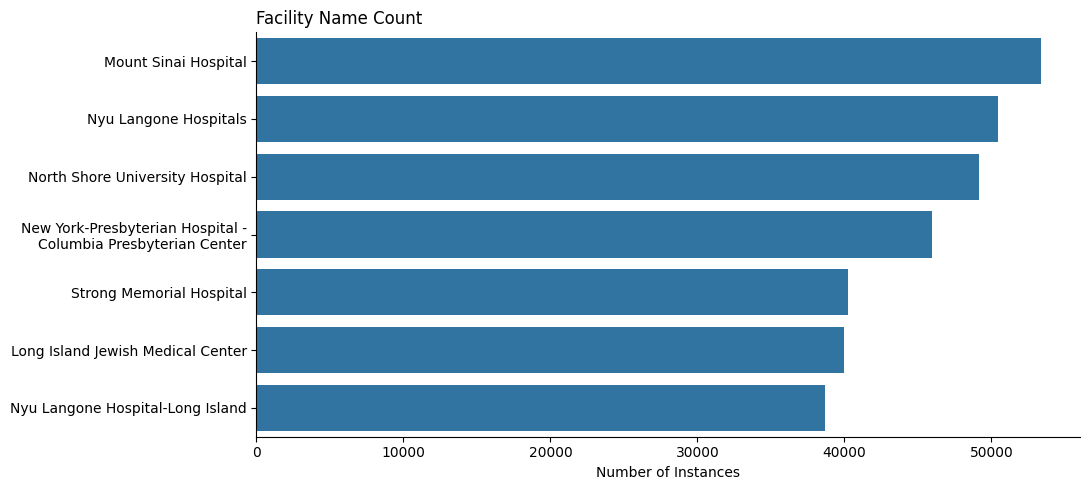

In [17]:
horizontal_barplot(df_temp.head(7), col, figsize=(11, 5))

### Age Group

The **age group** variable describess the patient's age in years at the time of admission, grouped into age ranges.

In [18]:
col = 'age_group'
df_temp = get_number_of_instances(df, col)
df_temp

,age_group,number_of_instances,percent
0,70 or Older,706970,32.182733
1,50-69,581333,26.463477
2,30-49,423270,19.268124
3,0-17,301927,13.744340
4,18-29,183237,8.341326


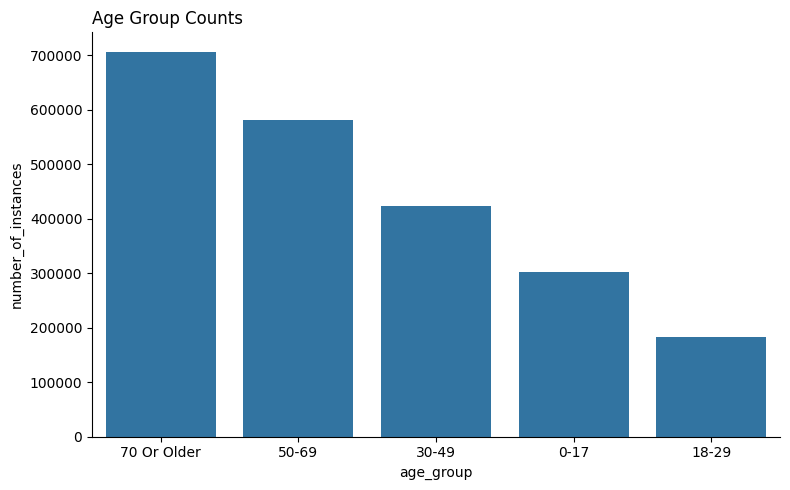

In [19]:
barplot(df_temp, col, figsize = (8, 5))

In [20]:
df_temp["cumulitive"] = df_temp.iloc[:, 2].cumsum()
df_temp[[col, "cumulitive"]]

,age_group,cumulitive
0,70 or Older,32.182733
1,50-69,58.646210
2,30-49,77.914334
3,0-17,91.658674
4,18-29,100.000000


### Gender

The **gender** variable identifies the patient's denger as a one-character value. The values are M for Male, F for Female, and U for Unknown.

In [21]:
col = "gender"
df_temp = get_number_of_instances(df, col)
df_temp

,gender,number_of_instances,percent
0,F,1195617,54.426952
1,M,1000735,45.555522
2,U,385,0.017526


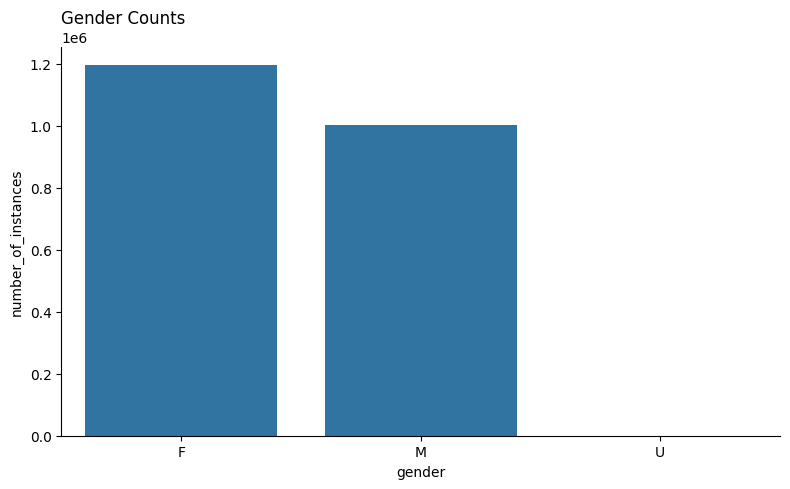

In [22]:
barplot(df_temp, col, figsize = (8, 5))

### Race

The **race** variable contains patient's race.

In [23]:
col = "race"
df_temp = get_number_of_instances(df, col)
df_temp

,race,number_of_instances,percent
0,White,1147354,52.229921
1,Other Race,620872,28.263374
2,Black/African American,395419,18.000289
3,Multi-racial,33092,1.506416


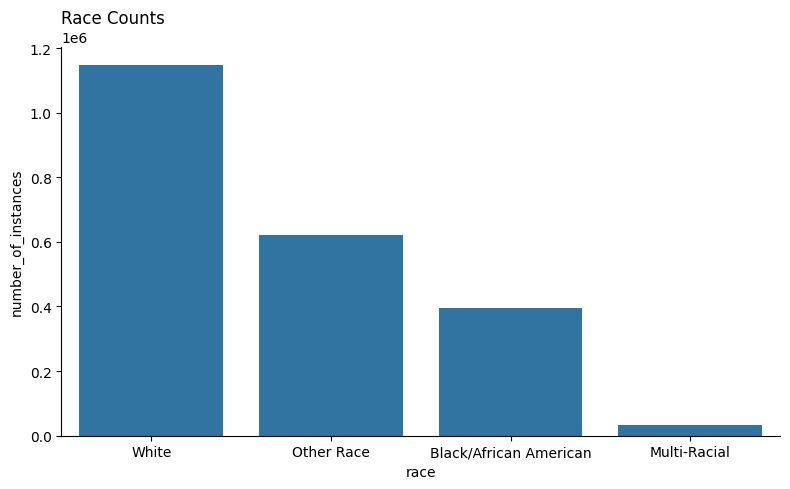

In [24]:
barplot(df_temp, "race", figsize = (8, 5))

### Ethnicity

The **ethnicity** variable identifies the ethnicity of a patient.

In [25]:
col = "ethnicity"
df_temp = get_number_of_instances(df, col)
df_temp

,ethnicity,number_of_instances,percent
0,Not Span/Hispanic,1540538,70.128468
1,Spanish/Hispanic,363988,16.569485
2,Unknown,289643,13.185147
3,Multi-ethnic,2568,0.116901


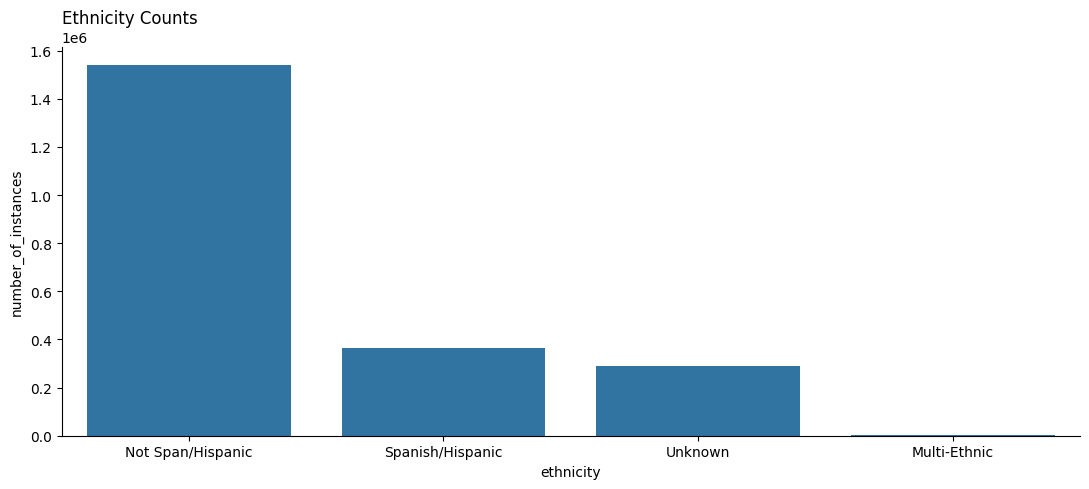

In [26]:
barplot(df_temp, col)

### Length of Stay

The **length of stay** variable contains the total number of patient days for the discharge, excluding leave-of-absence days.

In [27]:
col = "length_of_stay"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,length_of_stay,5.810259,3.0,2.0,2.0,6.0,8.826429,77.905848


In [28]:
df[col].sum().item()

12763611

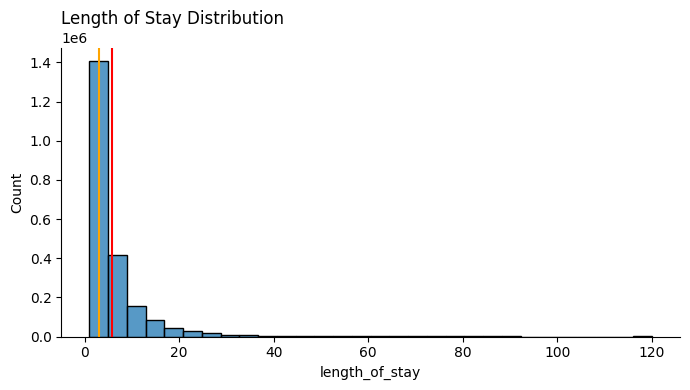

In [29]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x=col,
    bins=30,
    kde=False
)

sns.despine()
plt.axvline(df_temp['mean'].item(), color = "red")
plt.axvline(df_temp['median'].item(), color = "orange")
plt.title("Length of Stay Distribution", loc="left")
# plt.xlabel("Length of Stay Days")
# plt.ylabel("Number of Discharges")
plt.tight_layout()
plt.show()

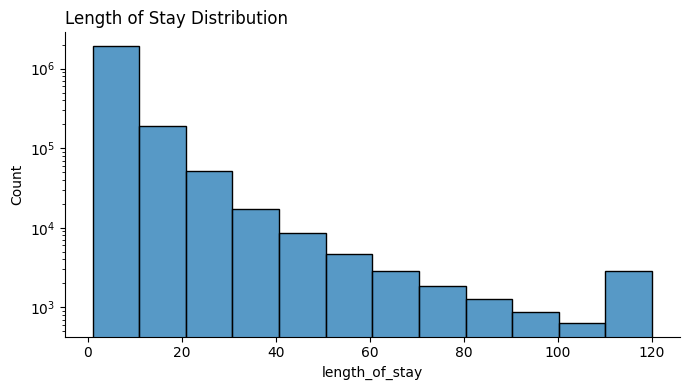

In [30]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x=col,
    bins=12,
    kde=False
)

sns.despine()
plt.title("Length of Stay Distribution", loc="left")
plt.yscale("log")
plt.tight_layout()
plt.show()

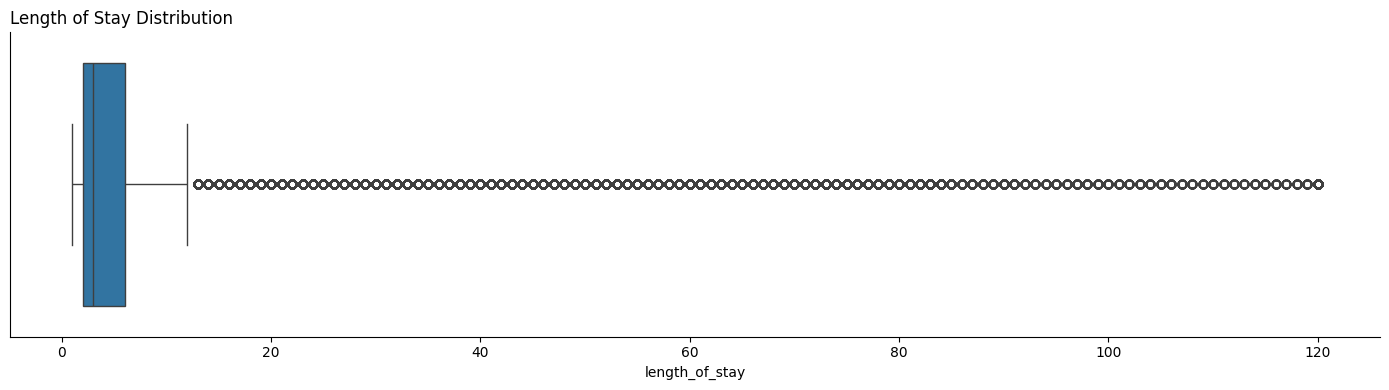

In [31]:
plt.figure(figsize=(14, 4))

sns.boxplot(
    x = df[col]
    )

sns.despine()
plt.title("Length of Stay Distribution", loc="left")
plt.yticks([])
plt.tight_layout()
plt.show()

In [32]:
df["length_of_stay"].quantile(q= [0.15, 0.25, 0.5, 0.75, 0.95, 0.99])

,length_of_stay
0.15,1.0
0.25,2.0
0.50,3.0
0.75,6.0
0.95,19.0
0.99,42.0


### Type of Admission

The **type of admission** variable describes the manner in which the patient was admitted to the health care facility.

In [33]:
col = "type_of_admission"
df_temp = get_number_of_instances(df, col)
df_temp

,type_of_admission,number_of_instances,percent
0,Emergency,1460204,66.471498
1,Elective,355896,16.201120
2,Newborn,198219,9.023338
3,Urgent,168716,7.680300
4,Trauma,10050,0.457497
5,Not Available,3652,0.166247


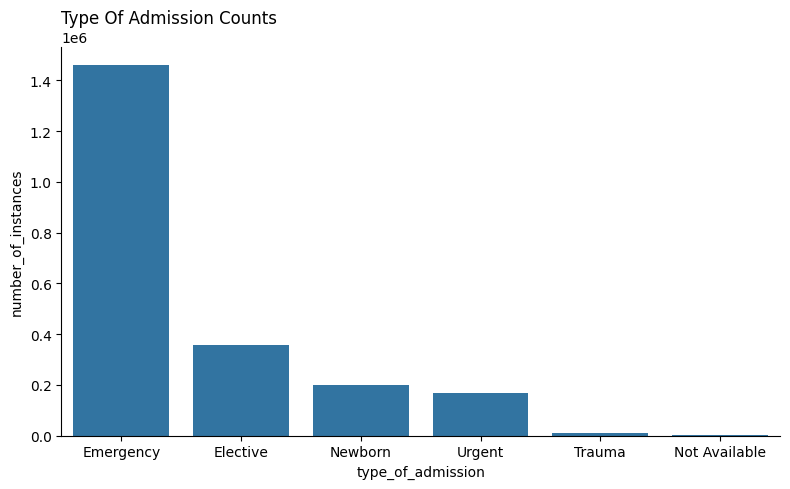

In [34]:
barplot(df_temp, col, figsize=(8, 5))

### Patient Disposition

The **patient disposition** variable shows the patient status after leaving the hospital. It tells what happened at discharge, such as whether the patient went home, was transferred to another facility, etc.

In [35]:
col = "patient_disposition"
df_temp = get_number_of_instances(df, col)
df_temp

,patient_disposition,number_of_instances,percent
0,Home or Self Care,1441830,65.635076
1,Home w/ Home Health Services,299705,13.643190
2,Skilled Nursing Home,211258,9.616900
3,Left Against Medical Advice,57701,2.626669
4,Expired,54460,2.479132
5,Short-term Hospital,38487,1.752008
6,Inpatient Rehabilitation Facility,35860,1.632421
7,Hospice - Home,11241,0.511714
8,Psychiatric Hospital or Unit of Hosp,9954,0.453127
9,Hospice - Medical Facility,9856,0.448665


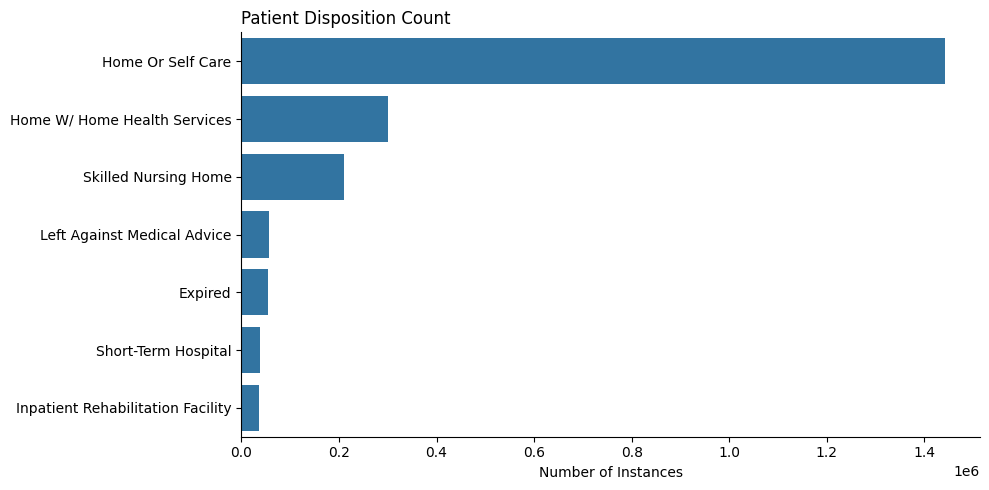

In [36]:
horizontal_barplot(df_temp.head(7), col, figsize=(10,5))

In [37]:
#the persentage of the first 5 values
df_temp.iloc[:5, 2].sum().round().item()

94.0

### CCSR Diagnosis Description

The **ccsr diagnosis description** variable contains the diagnosis category name assigned using the AHRQ Clinical Classification Software Refined (CCSR) system. CCSR groups detailed ICD-10-CM diagnosis codes into broader clinical categories, so the values are more readable than raw diagnosis codes.

In [38]:
col = "ccsr_diagnosis_description"
df_temp = get_number_of_instances(df, col)
find_num_groups(df_temp, 90)[0]

137

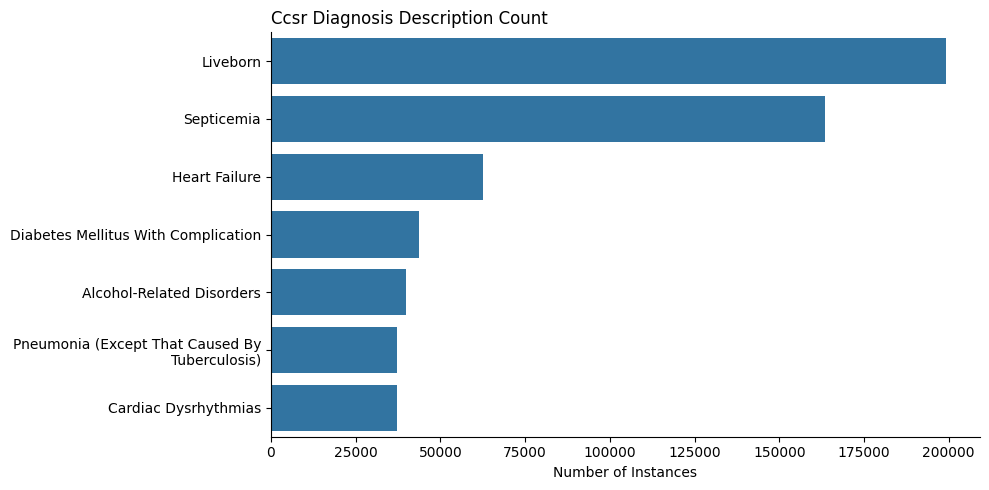

In [39]:
horizontal_barplot(df_temp.head(7), col, figsize = (10, 5))

### APR DRG Description

The **apr drg description** variable contains the description for the All Patients Refined Diagnosis Related Group (APR-DRG) assigned to the discharge. APR-DRG is a classification system that groups hospital cases into clinically similar categories. The description is the readable label for the APR-DRG code, rather than the code itself.

In [40]:
col = "apr_drg_description"
df_temp = get_number_of_instances(df, col)
df_temp.head(7)

,apr_drg_description,number_of_instances,percent
0,"NEONATE BIRTH WEIGHT > 2499 GRAMS, NORMAL NEWB...",168494,7.670194
1,SEPTICEMIA AND DISSEMINATED INFECTIONS,144367,6.571884
2,VAGINAL DELIVERY,123398,5.617332
3,HEART FAILURE,60015,2.732007
4,CESAREAN SECTION WITHOUT STERILIZATION,59419,2.704875
5,OTHER PNEUMONIA,33096,1.506598
6,KIDNEY AND URINARY TRACT INFECTIONS,32638,1.485749


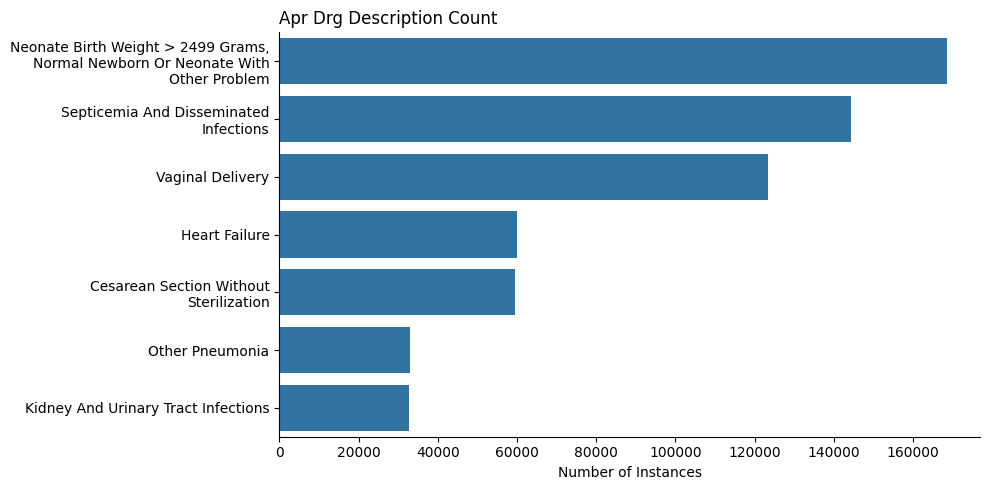

In [41]:
horizontal_barplot(df_temp.head(7), col, figsize=(10, 5))

### APR MDC Description

The **apr mdc description** variable contains the description for the All Patient Refined Major Diagnostic Category (APR MDC) assigned to the discharge. APR MDC is a broader grouping connected to the APR-DRG classification system. It represents a major diagnostic category, usually based on a body system or major clinical area.

In [42]:
col = "apr_mdc_description"
df_temp = get_number_of_instances(df, col)
df_temp.head(7)

,apr_mdc_description,number_of_instances,percent
0,DISEASES AND DISORDERS OF THE CIRCULATORY SYSTEM,277625,12.638063
1,"PREGNANCY, CHILDBIRTH AND THE PUERPERIUM",219991,10.014444
2,NEWBORNS AND OTHER NEONATES WITH CONDTN ORIG I...,203604,9.268474
3,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",183022,8.331539
4,DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM,180502,8.216823
5,DISEASES AND DISORDERS OF THE DIGESTIVE SYSTEM,172157,7.836942
6,DISEASES AND DISORDERS OF THE MUSCULOSKELETAL ...,171033,7.785775


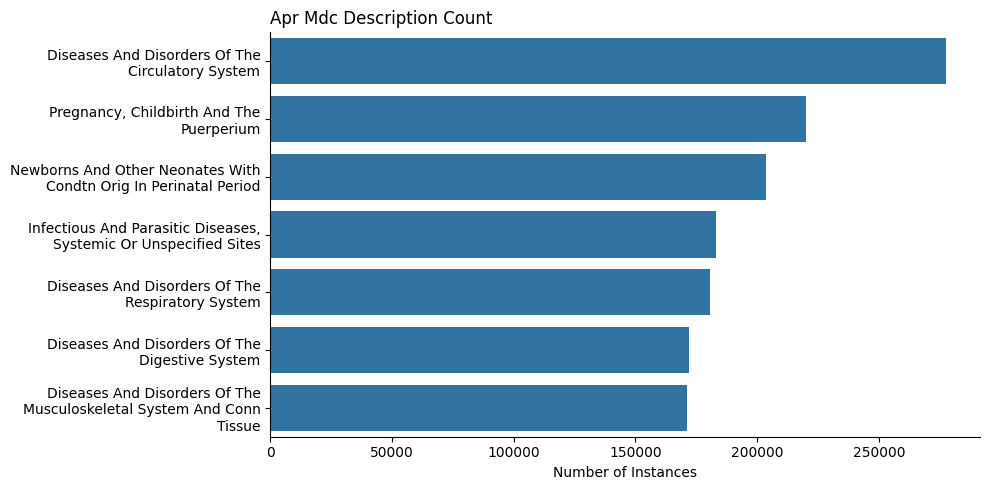

In [43]:
horizontal_barplot(df_temp.head(7), col, figsize = (10, 5))

In [44]:
find_num_groups(df_temp, 80)[0]

10

### APR Severity of Illness Code

The **apr severity of Illness code** variable describess the severity of Illness code assigned to the discharge. It is stored as a digit with values 0, 1, 2, 3, and 4. These codes correspond to severity levels used in the APR system, from Undetermined to Extreme.

In [45]:
col = "apr_severity_of_illness_code"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,apr_severity_of_illness_code,2.145497,2.0,2.0,1.0,3.0,0.925232,0.856053


### APR Severity of Illness



The **apr severity of illness** variable indentifies the All Patient Refined Severity of Illness (APR SOI) level assigned to the discharge. It has the values Undetermined, Minor, Moderate, Major, and Extreme.

In [46]:
col = "apr_severity_of_illness"
df_temp = get_number_of_instances(df, col)
df_temp

,apr_severity_of_illness,number_of_instances,percent
0,Moderate,820465,37.349259
1,Minor,619207,28.187580
2,Major,573480,26.105993
3,Extreme,183129,8.336410
4,Undetermined,456,0.020758


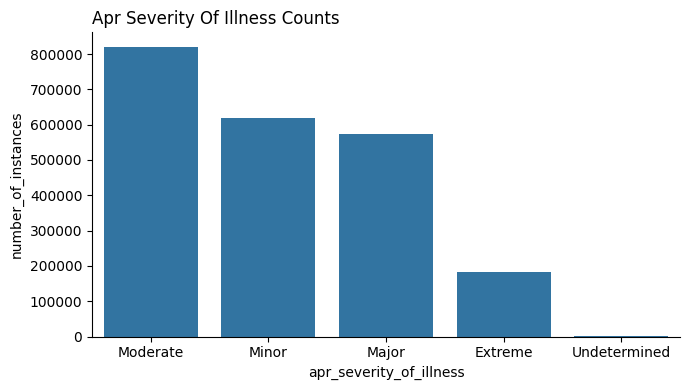

In [47]:
barplot(df_temp, col, figsize=(7, 4))

### APR Risk of Mortality

The **apr risk of mortality** variable contains the All Patient Refined Risk of Mortality (APR ROM) level assigned to the discharge. It represents the patient’s estimated mortality risk category within the APR system.

In [48]:
col = "apr_risk_of_mortality"
df_temp = get_number_of_instances(df, col)
df_temp

,apr_risk_of_mortality,number_of_instances,percent
0,Minor,1108093,50.442679
1,Moderate,477108,21.718940
2,Major,440239,20.040587
3,Extreme,170841,7.777035
4,Undetermined,456,0.020758


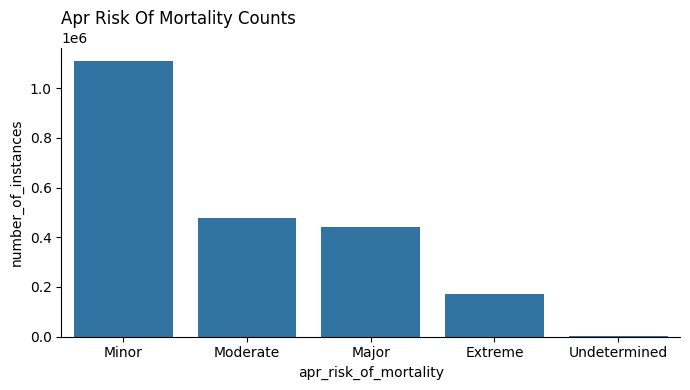

In [49]:
barplot(df_temp, col, figsize=(7, 4))

### APR Medical Surgical

The **apr medical surgical** variable contains the APR-DRG medical/surgical classification assigned to the discharge. It indicates whether the assigned APR-DRG category is classified as Medical, Surgical, or Not Applicable. “Medical” generally refers to cases managed without a major operating-room procedure, while “Surgical” refers to cases grouped into surgical APR-DRG categories.

In [50]:
col = "apr_medical_surgical"
df_temp = get_number_of_instances(df, col)
df_temp

,apr_medical_surgical,number_of_instances,percent
0,Medical,1686244,76.761306
1,Surgical,510037,23.217936
2,Not Applicable,456,0.020758


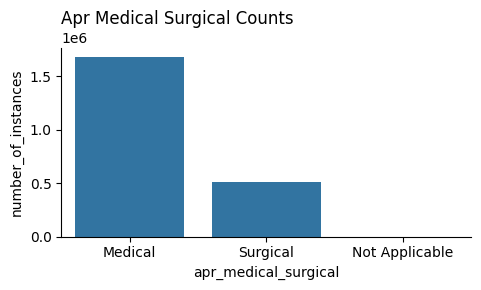

In [51]:
barplot(df_temp, col, figsize = (5, 3))

### Payment Typology

The **payment topology** variable describess the primary source of payment listed for the discharge. It identifies the first payer category associated with the hospital stay, such as an insurance program or another payment source

In [52]:
col = "payment_typology_1"
df_temp = get_number_of_instances(df, col)
df_temp

,payment_typology_1,number_of_instances,percent
0,Medicare,929267,42.306523
1,Medicaid,635606,28.937087
2,Private Health Insurance,317827,14.469636
3,Blue Cross/Blue Shield,204165,9.294972
4,Self-Pay,34786,1.583694
5,"Managed Care, Unspecified",30320,1.380372
6,Miscellaneous/Other,21764,0.990845
7,Federal/State/Local/VA,21140,0.962436
8,Department of Corrections,1635,0.074436


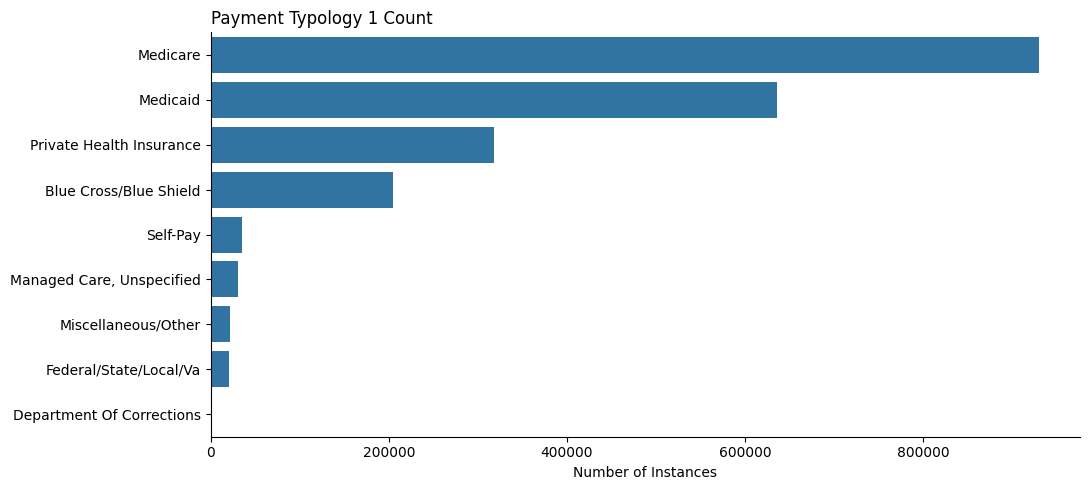

In [53]:
horizontal_barplot(df_temp, col)

### Emergency Department Indicator

The **emergency department indicator** variable shows whether the discharge record included an Emergency Department revenue code. The value is Y if the record contained an Emergency Department revenue code from the 045X series, and N otherwise.

In [54]:
col = "emergency_department_indicator"
df_temp = get_number_of_instances(df, col)
df_temp

,emergency_department_indicator,number_of_instances,percent
0,Y,1377141,62.690299
1,N,819596,37.309701


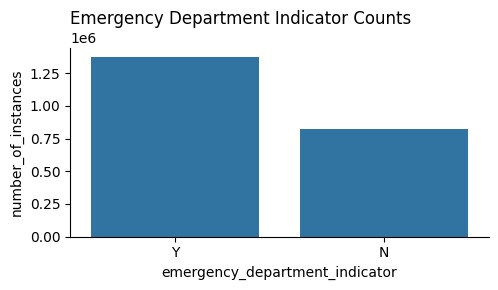

In [55]:
barplot(df_temp, col, figsize = (5, 3))

### Has ED Services

The **has ed services** variable indicates whether the discharge record included an Emergency Department revenue code. Represented by numbers 0 and 1. Has the same dis

### Total Charges

The **total charges** variable contains the total charges for the hospital discharge. It represents the amount charged by the hospital for the stay.

In [56]:
col = "total_charges"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,total_charges,90625.430221,47243.79,13890.0,23576.38,94515.16,189402.170295,3.587318e+10


In [57]:
df[col].quantile([0.15, 0.25, 0.5, 0.75, 0.95, 0.99])

,total_charges
0.15,16580.1040
0.25,23576.3800
0.50,47243.7900
0.75,94515.1600
0.95,289019.8960
0.99,715906.0144


In [58]:
mask = df[col] >= 2e5

df[mask].shape[0]

198667

In [59]:
df[col].agg(['min', 'max'])

,total_charges
min,0.00
max,19694856.95


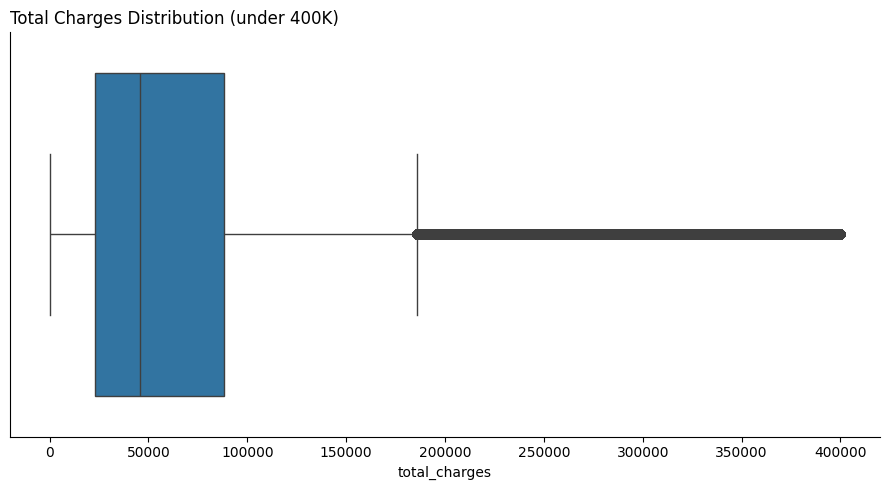

In [60]:
mask = df[col] <= 4e5

plt.figure(figsize=(9,5))

sns.boxplot(
    x = df.loc[mask, col]
    )

sns.despine()
plt.title(f"Total Charges Distribution (under 400K)", loc = "left")
plt.yticks([])
plt.tight_layout()
plt.show()

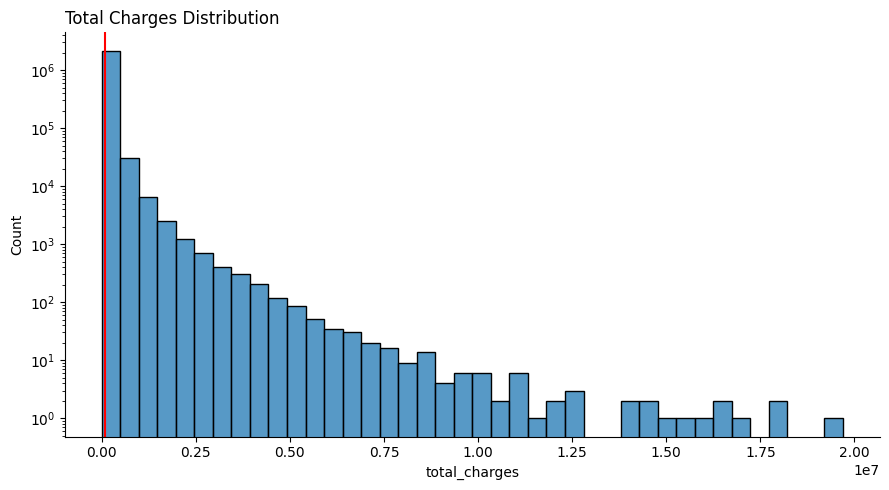

In [61]:
plt.figure(figsize  = (9, 5))

sns.histplot(
    data = df,
    x = col,
    bins = 40,
    kde = False

)

sns.despine()
plt.axvline(df_temp["mean"].item(), color = "red")
plt.title(f"Total Charges Distribution", loc = "left")
plt.yscale("log")
plt.tight_layout()
plt.show()

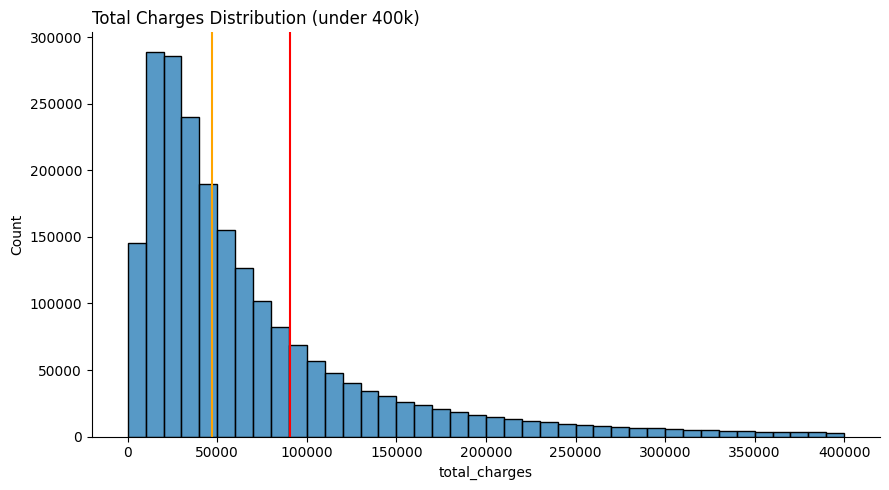

In [62]:
mask = df[col] < 4e5

plt.figure(figsize  = (9, 5))

sns.histplot(
    data = df[mask],
    x = col,
    bins = 40,
    kde = False

)

sns.despine()
plt.title(f"Total Charges Distribution (under 400k)", loc = "left")
plt.axvline(df_temp["mean"].item(), color = "red")
plt.axvline(df_temp["median"].item(), color = "orange")
plt.tight_layout()
plt.show()

### Total Costs

The **total costs** variable contains the total estimated cost for the hospital discharge (cost associated with providing care).

In [63]:
col = "total_costs"
df_temp = get_summary_stats(df, col)
df_temp

index,column_name,mean,median,mode,q1,q3,std,var
0,total_costs,26416.584062,14110.45,3191.05,7415.88,27788.34,55372.286312,3.066090e+09


In [64]:
df[col].quantile([0.25, 0.5, 0.75, 0.95, 0.99])

,total_costs
0.25,7415.8800
0.50,14110.4500
0.75,27788.3400
0.95,82095.8160
0.99,202242.0572


In [65]:
mask = df[col] >= 1e5

df[mask].shape[0]

77933

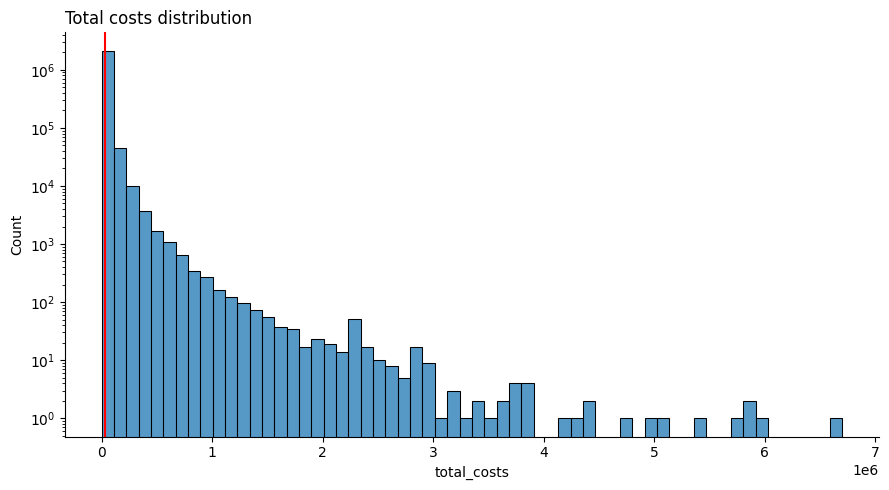

In [66]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data = df,
    x = col,
    bins = 60,
    kde = False
)

sns.despine()
plt.title("Total costs distribution", loc = "left")
plt.axvline(df_temp["mean"].item(), color = "red")
plt.yscale("log")
plt.tight_layout()
plt.show()

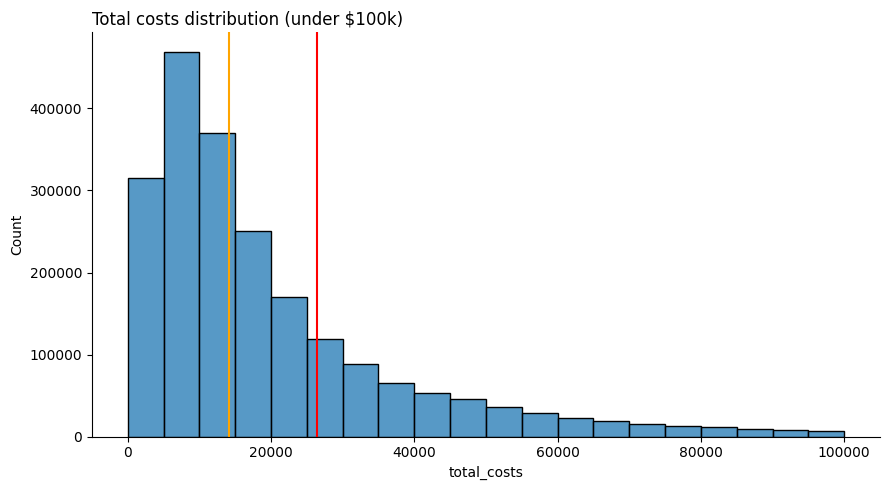

In [67]:
mask = df[col] <= 1e5

plt.figure(figsize=(9, 5))

sns.histplot(
    data = df[mask],
    x = col,
    bins = 20,
    kde = False
)


sns.despine()
plt.axvline(df_temp["mean"].item(), color = "red")
plt.axvline(df_temp["median"].item(), color = "orange")
plt.title("Total costs distribution (under $100k)", loc = "left")
plt.tight_layout()
plt.show()

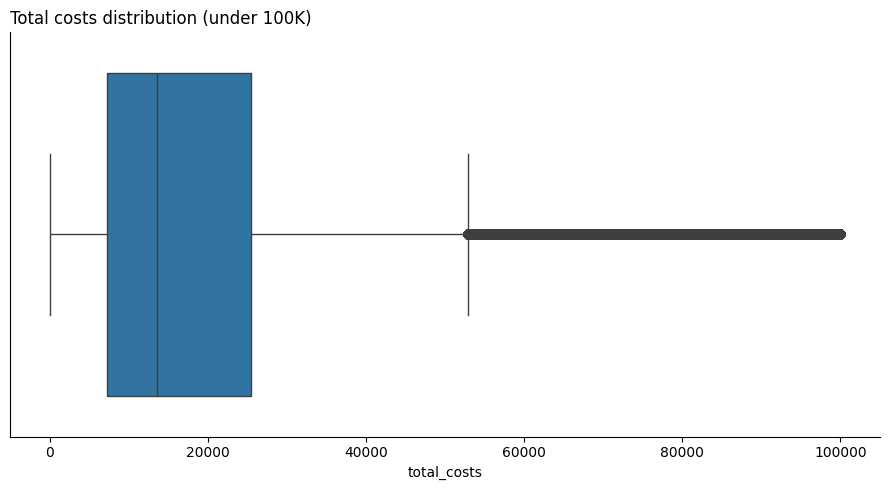

In [68]:
mask = df[col] <= 1e5

plt.figure(figsize=(9,5))

sns.boxplot(
    x = df.loc[mask, col]
    )

sns.despine()
plt.title("Total costs distribution (under 100K)", loc = "left")
plt.yticks([])
plt.tight_layout()
plt.show()

### CCSR Procedure Description

The **ccsr procedure description** variable identifiess the procedure category name assigned using the AHRQ Clinical Classification Software Refined (CCSR) system. It groups detailed ICD-10-PCS procedure codes into broader, more readable procedure categories.

In [69]:
col = "ccsr_procedure_description"
df_temp = get_number_of_instances(df, col)
df_temp.head(7)

,ccsr_procedure_description,number_of_instances,percent
0,SPONTANEOUS VAGINAL DELIVERY,115706,7.450612
1,CESAREAN SECTION,65817,4.238129
2,VACCINATIONS,64265,4.138192
3,NON-INVASIVE VENTILATION,54012,3.477974
4,"ADMINISTRATION OF THERAPEUTIC SUBSTANCES, NEC",51708,3.329614
5,ADMINISTRATION OF ANTIBIOTICS,43394,2.794253
6,TRANSFUSION OF BLOOD AND BLOOD PRODUCTS,38452,2.476025


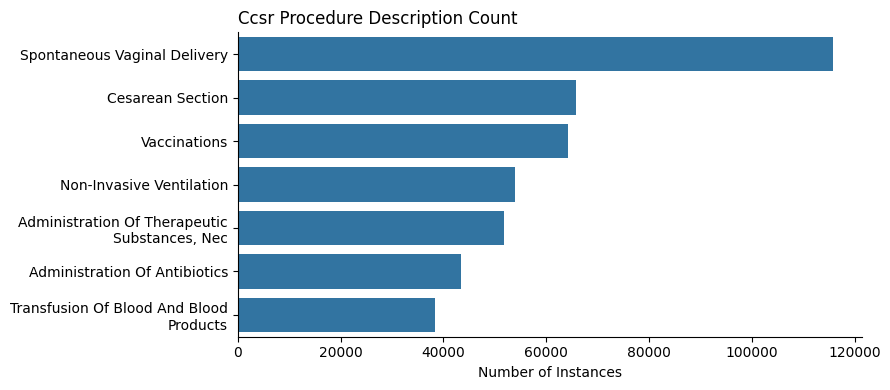

In [70]:
horizontal_barplot(df_temp.head(7), col, figsize=(9, 4))

In [71]:
num_nulls = get_num_nulls(df, col)
num_nulls, round(num_nulls/df[col].shape[0] * 100, 2 )

(np.int64(643764), np.float64(29.31))

### Has CCSR Procedure

The **has ccsr precedure** variable indicates whether a discharge record has a recorded CCSR procedure category.

In [72]:
col = "has_ccsr_procedure"
df_temp = get_number_of_instances(df, col)

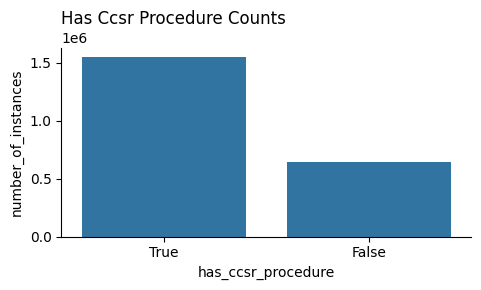

In [73]:
barplot(df_temp, col, figsize = (5,3))

# Relationships (Multivariate)

### Correlation: length of stay, severity of illness, total charges, total costs



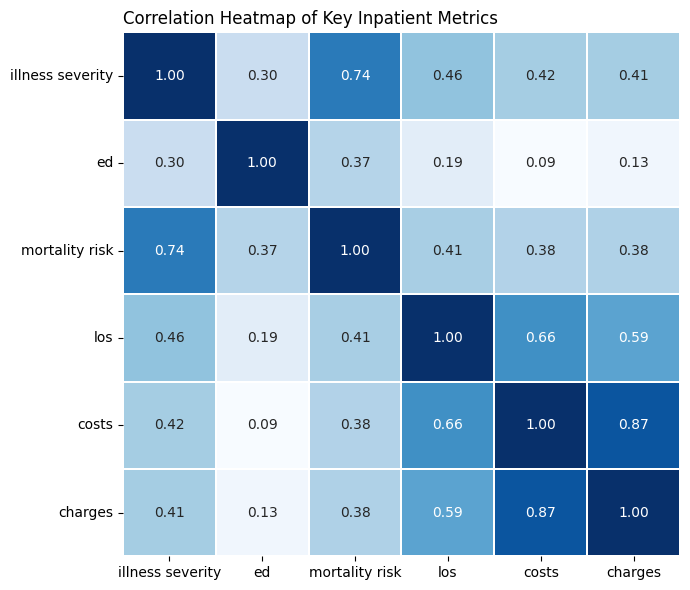

In [74]:
cols = [
    "apr_severity_of_illness_code",
    "has_ed_services",
    "mortality_risk_rank",
    "length_of_stay",
    "total_costs",
    "total_charges"
    ]

df_temp = df[cols].corr(
    method="spearman"
)

new_col_names = ["illness severity", "ed", "mortality risk", "los", "costs", "charges"]
mapping = dict(zip(df_temp.columns, new_col_names))
df_temp = df_temp.rename(columns=mapping, index=mapping)

plt.figure(figsize=(7, 6))

sns.heatmap(
    data = df_temp,
    fmt = ".2f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.title("Correlation Heatmap of Key Inpatient Metrics", loc = "left")
plt.yticks(rotation = 0)
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

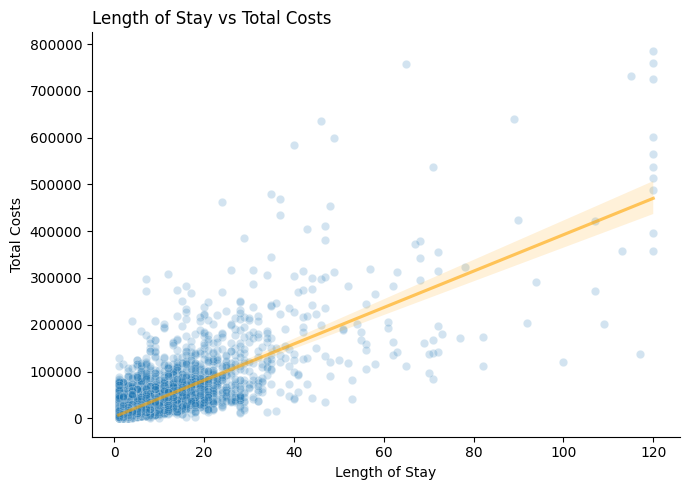

In [75]:
col1 = "length_of_stay"
col2 = "total_costs"

df_sample = df[[col1, col2]].sample(
    n=min(10_000, len(df)),
    random_state=42
).reset_index(drop = True)


plt.figure(figsize=(7, 5))

mask = df_sample[col2] <= 8e5
# mask = pd.Series([True] * df_sample.shape[0])

sns.scatterplot(
    data=df_sample[mask],
    x=col1,
    y=col2,
    alpha=0.2
)

sns.regplot(
    data=df_sample[mask],
    x=col1,
    y=col2,
    scatter=False,
    line_kws={"color": "orange", "alpha": 0.6}
)

sns.despine()
plt.title("Length of Stay vs Total Costs", loc="left")
plt.xlabel("Length of Stay")
plt.ylabel("Total Costs")
plt.tight_layout()
plt.show()

In [76]:
df_sample[mask].shape[0] / df_sample.shape[0] * 100

99.91

### Contingency tables: APR Severity of Illness, APR Risk Of Mortality

In [77]:
col1 = "apr_severity_of_illness"
col2 = "apr_risk_of_mortality"
ordered_cols = ["Extreme", "Major", "Moderate", "Minor", "Undetermined"]

ct =  pd.crosstab(
    df[col1],
    df[col2]
)

ct = ct.reindex(index = ordered_cols, columns = ordered_cols)
df_temp = ct.div(ct.sum(axis = 1), axis = 0) * 100 #row normalizes

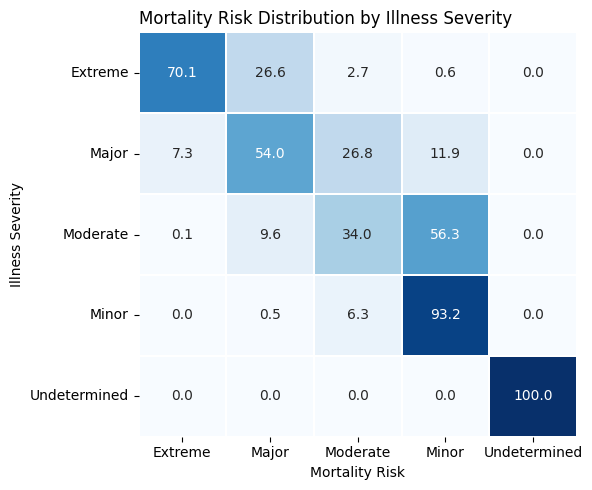

In [78]:
plt.figure(figsize = (6,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.ylabel("Illness Severity")
plt.xlabel("Mortality Risk")
plt.title("Mortality Risk Distribution by Illness Severity", loc = "left")
plt.tight_layout()
plt.show()

In [79]:
#column normalized
df_temp = ct.div(ct.sum(axis = 0), axis=1) * 100

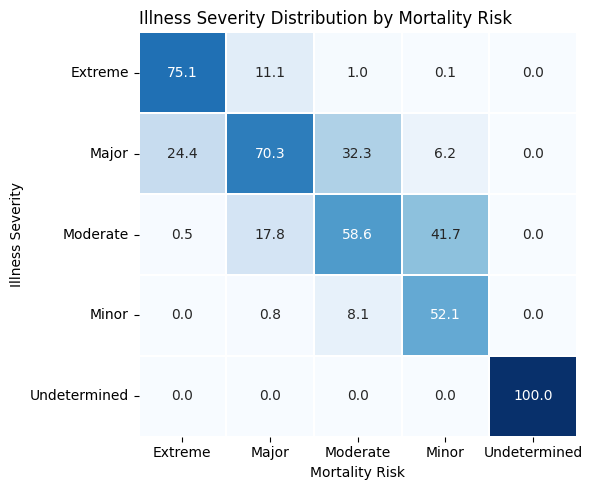

In [80]:
plt.figure(figsize = (6,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Mortality Risk")
plt.ylabel("Illness Severity")
plt.title("Illness Severity Distribution by Mortality Risk", loc = "left")
plt.tight_layout()
plt.show()

In [81]:
#joint distribution
df_temp = ct / ct.to_numpy().sum() * 100

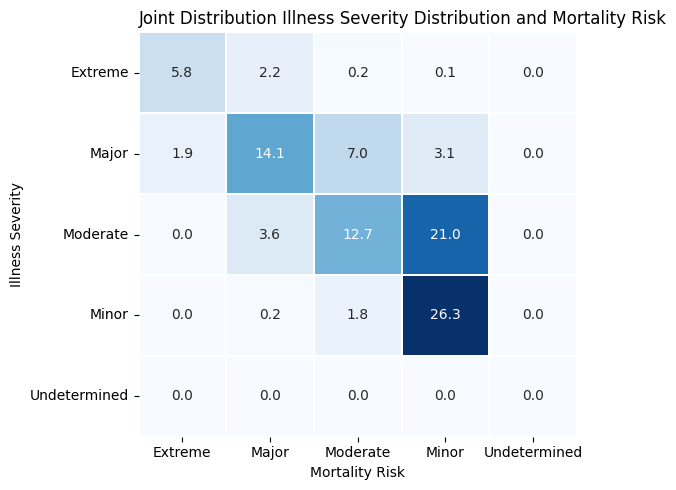

In [82]:
plt.figure(figsize = (6,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Mortality Risk")
plt.ylabel("Illness Severity")
plt.title("Joint Distribution Illness Severity Distribution and Mortality Risk", loc = "left")
plt.tight_layout()
plt.show()

### Contingency tables: APR Severity of Illness, Patient Disposiiton

In [83]:
col1 = "patient_disposition"
col2 = "apr_severity_of_illness"
pd_order = [
    "Expired",
    "Left Against Medical Advice",
    "Skilled Nursing Home",
    "Home w/ Home Health Services",
    "Home or Self Care",
    ]
si_order = [
    "Extreme",
    "Major",
    "Moderate",
    "Minor",
    "Undetermined"
    ]
mask = df[col1].isin(pd_order)


ct =  pd.crosstab(
    df.loc[mask, col1],
    df.loc[:, col2],
) * 100

ct = ct.reindex(columns = si_order, index = pd_order)

In [84]:
#index normalized
df_temp = ct.div(ct.sum(axis = 1), axis = 0) * 100

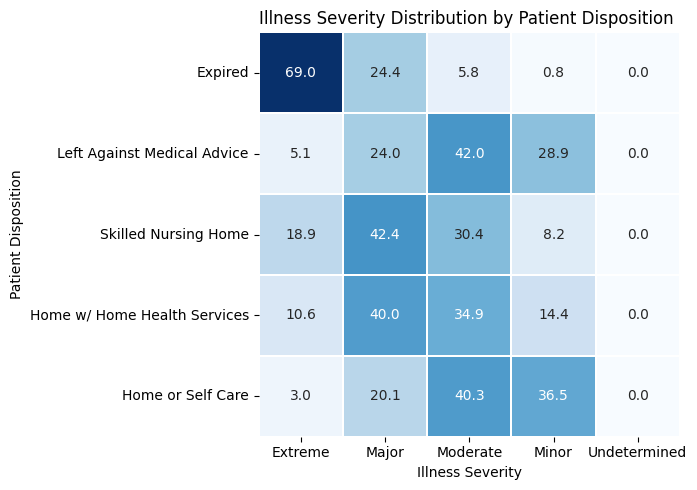

In [85]:
plt.figure(figsize = (7,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Illness Severity")
plt.ylabel("Patient Disposition")
plt.title("Illness Severity Distribution by Patient Disposition", loc = "left")
plt.tight_layout()
plt.show()

In [86]:
#column normalized
df_temp = ct.div(ct.sum(axis = 0), axis = 1) * 100

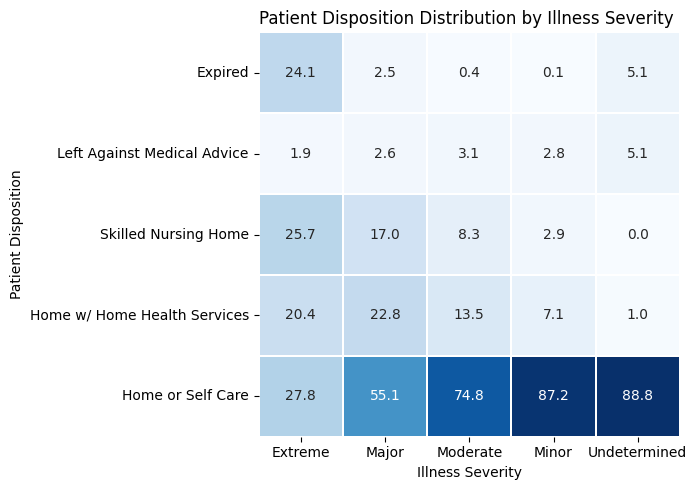

In [87]:
plt.figure(figsize = (7,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Illness Severity")
plt.ylabel("Patient Disposition")
plt.title("Patient Disposition Distribution by Illness Severity", loc = "left")
plt.tight_layout()
plt.show()

In [88]:
#joint distribution
df_temp = ct / ct.to_numpy().sum() * 100

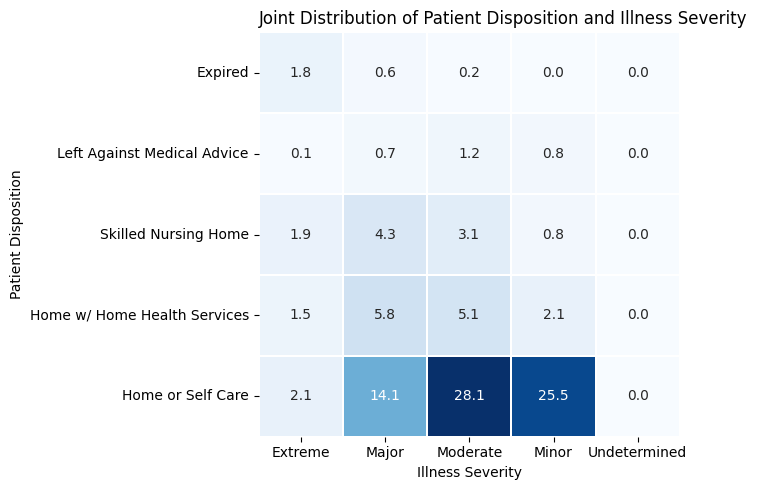

In [89]:
plt.figure(figsize = (7,5))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Illness Severity")
plt.ylabel("Patient Disposition")
plt.title("Joint Distribution of Patient Disposition and Illness Severity", loc = "left")
plt.tight_layout()
plt.show()

### Contingency tables: APR MDC Description, APR Risk of Mortality

In [90]:
col1 = "apr_mdc_description"
col2 = "apr_risk_of_mortality"
ordered_cols = ["Extreme", "Major", "Moderate", "Minor", "Undetermined"]
apr_mdc_short_lables = {
    "DISEASES AND DISORDERS OF THE CIRCULATORY SYSTEM": "Circulatory System",
    "PREGNANCY, CHILDBIRTH AND THE PUERPERIUM": "Pregnancy & Childbirth",
    "NEWBORNS AND OTHER NEONATES WITH CONDTN ORIG IN PERINATAL PERIOD": "Newborns & Neonates",
    "INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR UNSPECIFIED SITES": "Infectious & Parasitic Diseases",
    "DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM": "Respiratory System",
    "DISEASES AND DISORDERS OF THE DIGESTIVE SYSTEM": "Digestive System",
    "DISEASES AND DISORDERS OF THE MUSCULOSKELETAL SYSTEM AND CONN TISSUE": "Musculoskeletal System",
    "DISEASES AND DISORDERS OF THE NERVOUS SYSTEM": "Nervous System",
    "DISEASES AND DISORDERS OF THE KIDNEY AND URINARY TRACT": "Kidney & Urinary Tract",
    "MENTAL DISEASES AND DISORDERS": "Mental Diseases",
}

n_groups = find_num_groups(get_number_of_instances(df, col1), 80)[0]
n_groups

10

In [91]:
ct = pd.crosstab(
    df[col1],
    df[col2]
)

ct = ct.reindex(columns = ordered_cols)

In [92]:
df_temp = ct.loc[apr_mdc_short_lables.keys(), :].copy().rename(index = apr_mdc_short_lables)
df_temp = df_temp.div(df_temp.sum(axis= 1), axis=0) * 100 #normalized by index

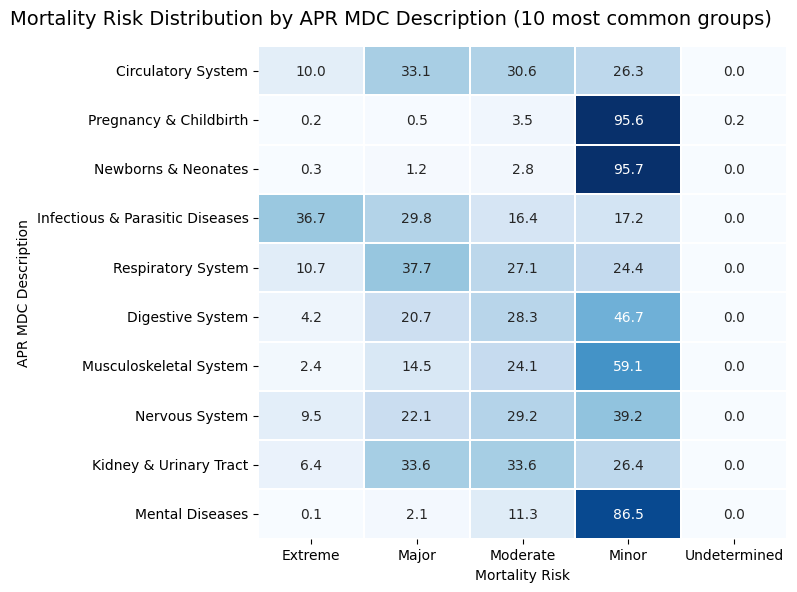

In [93]:
fig, _ = plt.subplots(figsize = (8, 6))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

fig.suptitle(
    "Mortality Risk Distribution by APR MDC Description (10 most common groups)",
    x=0.01,
    ha="left",
    fontsize=14
)

plt.yticks(rotation = 0)
plt.xlabel("Mortality Risk")
plt.ylabel("APR MDC Description")
plt.tight_layout()
plt.show()

In [94]:
df_temp = ct.loc[apr_mdc_short_lables.keys(), :].copy().rename(index = apr_mdc_short_lables)
df_temp = df_temp.div(df_temp.sum(axis= 0), axis=1) * 100 #normalized by columns

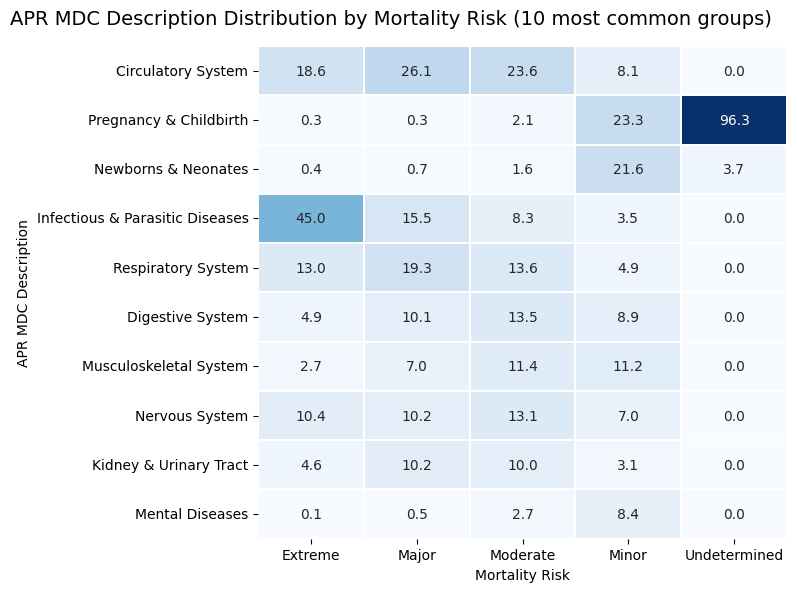

In [95]:
fig, _ = plt.subplots(figsize = (8, 6))

sns.heatmap(
    data = df_temp,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

fig.suptitle(
    "APR MDC Description Distribution by Mortality Risk (10 most common groups)",
    x=0.01,
    ha="left",
    fontsize=14
)

plt.yticks(rotation = 0)
plt.xlabel("Mortality Risk")
plt.ylabel("APR MDC Description")
plt.tight_layout()
plt.show()

### Group Difference: APR Severity of Illness, Total Costs, Total Charges, Lenght Of stay

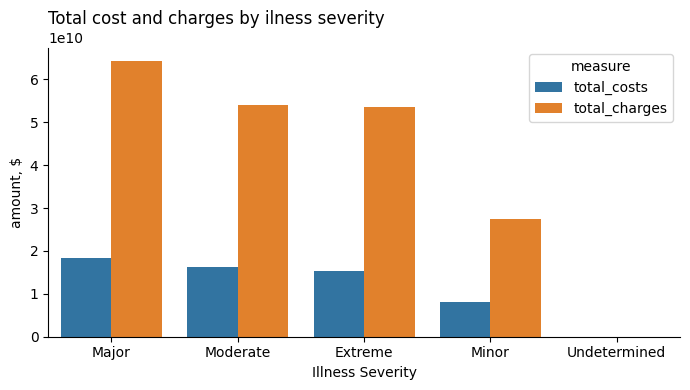

In [96]:
group_col = "apr_severity_of_illness"

df_temp = df.groupby(group_col)[["total_costs", "total_charges"]].agg(
  total_costs = ("total_costs", "sum"),
  total_charges = ("total_charges", "sum"),
).sort_values("total_costs", ascending = False).reset_index()


df_temp = df_temp.melt(
    id_vars = group_col,
    value_vars = ["total_costs", "total_charges"],
    var_name = "measure",
    value_name = "value"
)

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "value",
    hue = "measure"
)

sns.despine()
plt.ylabel("amount, $")
plt.xlabel("Illness Severity")
plt.title("Total cost and charges by ilness severity", loc = "left")
plt.tight_layout()
plt.show()

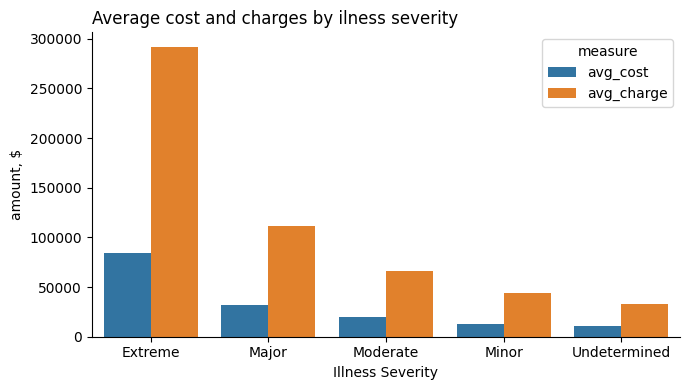

In [97]:
group_col = "apr_severity_of_illness"

df_temp = df.groupby(group_col)[["total_costs", "total_charges"]].agg(
  avg_cost = ("total_costs", "mean"),
  avg_charge = ("total_charges", "mean"),
).sort_values("avg_cost", ascending = False).reset_index()


df_temp = df_temp.melt(
    id_vars = group_col,
    value_vars = ["avg_cost", "avg_charge"],
    var_name = "measure",
    value_name = "value"
)

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "value",
    hue = "measure"
)

sns.despine()
plt.ylabel("amount, $")
plt.xlabel("Illness Severity")
plt.title("Average cost and charges by ilness severity", loc = "left")
plt.tight_layout()
plt.show()

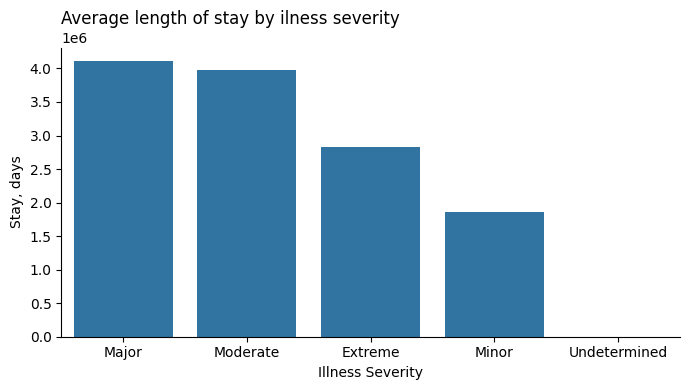

In [98]:
group_col = "apr_severity_of_illness"

df_temp = df.groupby(group_col)["length_of_stay"].agg(
  total = "sum"
).sort_values("total", ascending = False).reset_index()

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "total",
    legend=False
)

sns.despine()
plt.ylabel("Stay, days")
plt.xlabel("Illness Severity")
plt.title("Average length of stay by ilness severity", loc = "left")
plt.tight_layout()
plt.show()

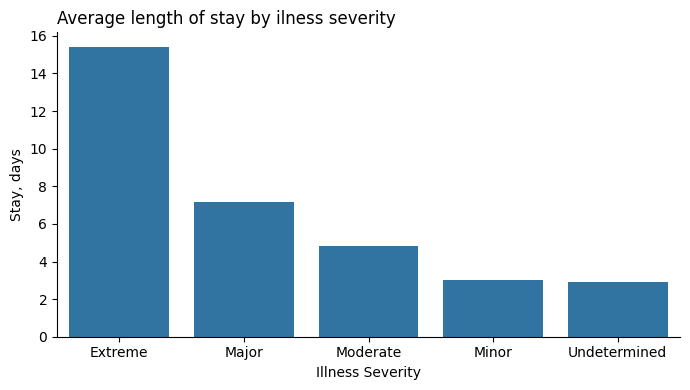

In [99]:
group_col = "apr_severity_of_illness"

df_temp = df.groupby(group_col)["length_of_stay"].agg(
  mean = "mean"
).sort_values("mean", ascending = False).reset_index()

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "mean",
    legend=False
)

sns.despine()
plt.ylabel("Stay, days")
plt.xlabel("Illness Severity")
plt.title("Average length of stay by ilness severity", loc = "left")
plt.tight_layout()
plt.show()

### Group Difference: APR Risk of Mortality Total Costs, Total Charges, Length of Stay

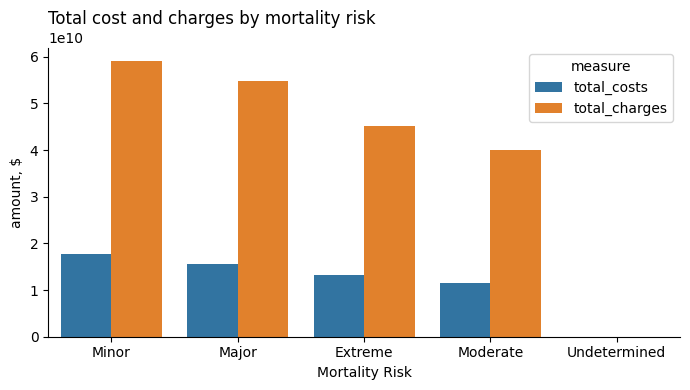

In [100]:
group_col = "apr_risk_of_mortality"

df_temp = df.groupby(group_col)[["total_costs", "total_charges"]].agg(
  total_costs = ("total_costs", "sum"),
  total_charges = ("total_charges", "sum"),
).sort_values("total_costs", ascending = False).reset_index()


df_temp = df_temp.melt(
    id_vars = group_col,
    value_vars = ["total_costs", "total_charges"],
    var_name = "measure",
    value_name = "value"
)

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "value",
    hue = "measure"
)

sns.despine()
plt.ylabel("amount, $")
plt.xlabel("Mortality Risk")
plt.title("Total cost and charges by mortality risk", loc = "left")
plt.tight_layout()
plt.show()

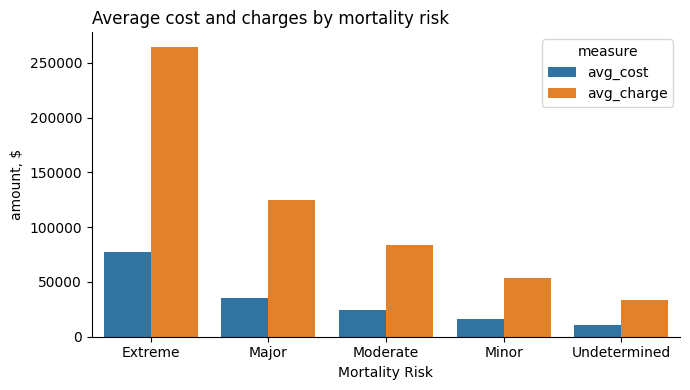

In [101]:
group_col = "apr_risk_of_mortality"

df_temp = df.groupby(group_col)[["total_costs", "total_charges"]].agg(
  avg_cost = ("total_costs", "mean"),
  avg_charge = ("total_charges", "mean"),
).sort_values("avg_cost", ascending = False).reset_index()


df_temp = df_temp.melt(
    id_vars = group_col,
    value_vars = ["avg_cost", "avg_charge"],
    var_name = "measure",
    value_name = "value"
)

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "value",
    hue = "measure"
)

sns.despine()
plt.ylabel("amount, $")
plt.xlabel("Mortality Risk")
plt.title("Average cost and charges by mortality risk", loc = "left")
plt.tight_layout()
plt.show()

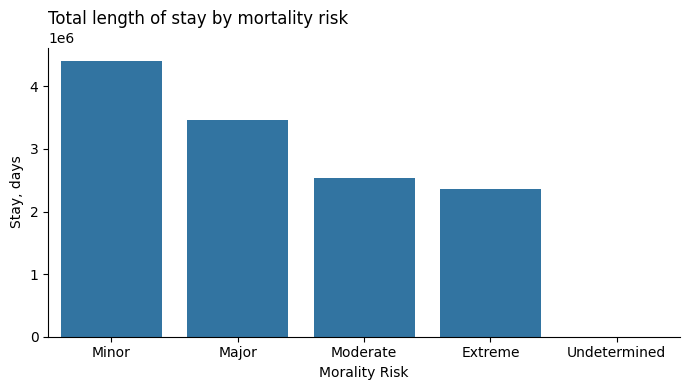

In [102]:
group_col = "apr_risk_of_mortality"

df_temp = df.groupby(group_col)["length_of_stay"].agg(
  total = "sum"
).sort_values("total", ascending = False).reset_index()

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "total",
    legend=False
)

sns.despine()
plt.ylabel("Stay, days")
plt.xlabel("Morality Risk")
plt.title("Total length of stay by mortality risk", loc = "left")
plt.tight_layout()
plt.show()

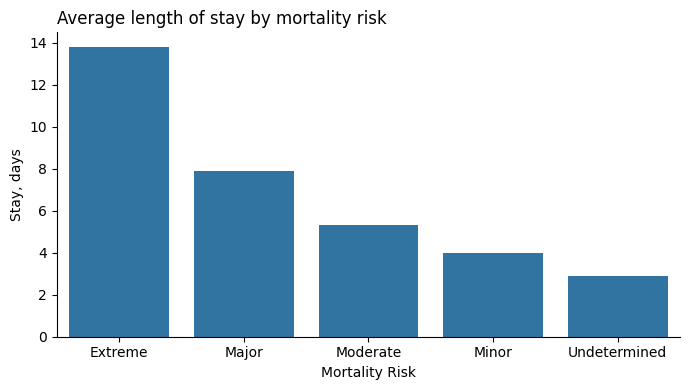

In [103]:
group_col = "apr_risk_of_mortality"

df_temp = df.groupby(group_col)["length_of_stay"].agg(
  mean = "mean"
).sort_values("mean", ascending = False).reset_index()

plt.figure(figsize = (7, 4))

sns.barplot(
    data = df_temp,
    x = group_col,
    y = "mean",
    legend=False
)

sns.despine()
plt.ylabel("Stay, days")
plt.xlabel("Mortality Risk")
plt.title("Average length of stay by mortality risk", loc = "left")
plt.tight_layout()
plt.show()

### Group Difference: APR MDC Description Total Costs, Total Charges, Length of Stay

Groups were selected separately for each metric. For each chart, the displayed categories represent the highest-ranking APR MDC groups for that specific measure, while all remaining groups were combined as “Other.”

In [104]:
#three plots: number of instances, total charges, average charges (correlation of summary stats?)

In [105]:
group_col = "apr_mdc_description"

summary_df = df.groupby(group_col)[[group_col, "total_costs", "total_charges", "length_of_stay"]].agg(
    number_of_instances = (group_col, "size"),
    total_cost = ("total_costs", "sum"),
    total_charge = ("total_charges", "sum"),
    total_los = ("length_of_stay", "sum"),
    avg_cost = ("total_costs", "mean"),
    avg_charge = ("total_charges", "mean"),
    avg_los = ("length_of_stay", "mean"),
    median_cost = ("total_costs", "median"),
    median_charge = ("total_charges", "median"),
    median_los = ("length_of_stay", "median")
).reset_index()

In [106]:
summary_df[["number_of_instances", "avg_cost", "avg_charge", "avg_los"]].corr()

,number_of_instances,avg_cost,avg_charge,avg_los
number_of_instances,1.000000,-0.197025,-0.179510,-0.184538
avg_cost,-0.197025,1.000000,0.983025,0.713992
avg_charge,-0.179510,0.983025,1.000000,0.622079
avg_los,-0.184538,0.713992,0.622079,1.000000


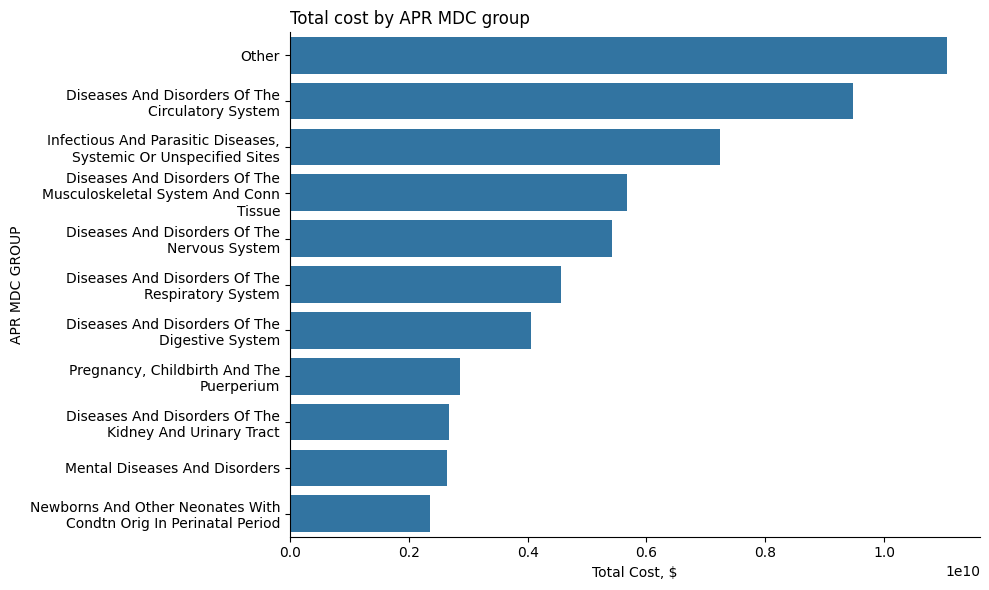

In [107]:
n_groups = 10 #summary_df.shape[0]
statistic_col = "total_cost"

top_groups = summary_df.sort_values(statistic_col, ascending=False).head(n_groups)[group_col]

df_temp = df.copy()

df_temp["apr_mdc_grouped"] = df_temp[group_col].where(
    df_temp[group_col].isin(top_groups),
    "OTHER"
)

df_plot = df_temp.groupby("apr_mdc_grouped").agg(
    total_cost = ('total_costs', "sum")
).sort_values(statistic_col, ascending=False).reset_index()


df_plot["apr_mdc_grouped"] = df_plot["apr_mdc_grouped"].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  "total_cost",
    y = "apr_mdc_grouped"
)

sns.despine()
plt.title("Total cost by APR MDC group", loc = "left")
plt.xlabel("Total Cost, $")
plt.ylabel("APR MDC GROUP")
plt.tight_layout()
plt.show()

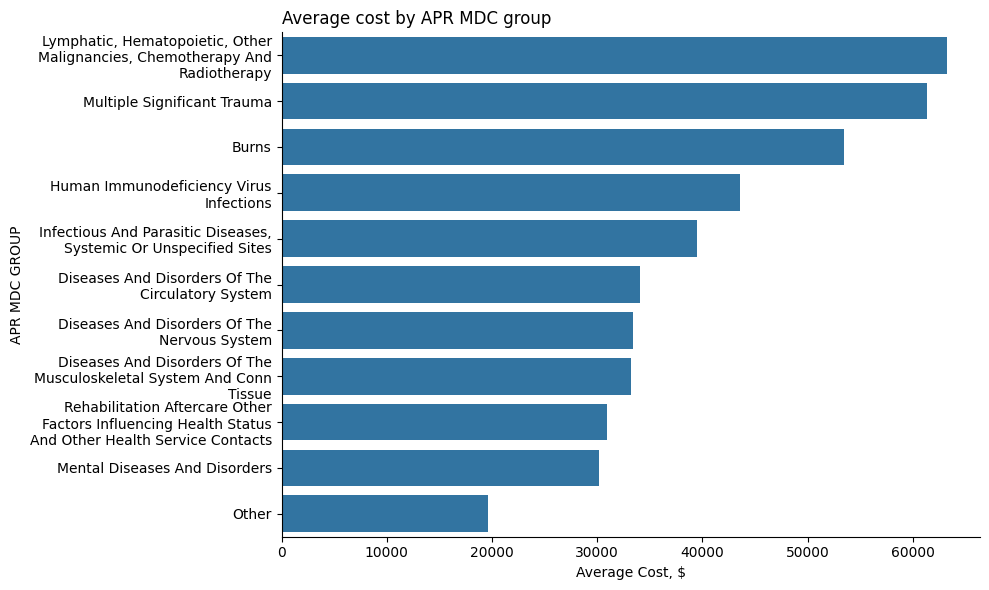

In [108]:
n_groups = 10 #summary_df.shape[0]
statistic_col = "avg_cost"

top_groups = summary_df.sort_values(statistic_col, ascending=False).head(n_groups)[group_col]

df_temp = df.copy()

df_temp["apr_mdc_grouped"] = df_temp[group_col].where(
    df_temp[group_col].isin(top_groups),
    "OTHER"
)

df_plot = df_temp.groupby("apr_mdc_grouped").agg(
    avg_cost = ('total_costs', "mean")
).sort_values(statistic_col, ascending=False).reset_index()


df_plot["apr_mdc_grouped"] = df_plot["apr_mdc_grouped"].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  "avg_cost",
    y = "apr_mdc_grouped"
)

sns.despine()
plt.title("Average cost by APR MDC group", loc = "left")
plt.xlabel("Average Cost, $")
plt.ylabel("APR MDC GROUP")
plt.tight_layout()
plt.show()

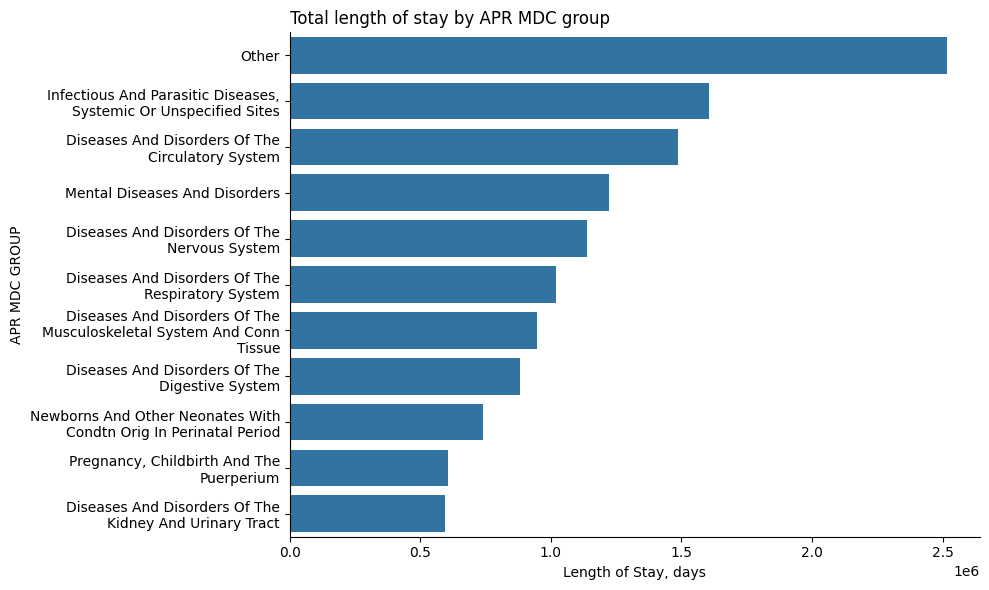

In [109]:
n_groups = 10 #summary_df.shape[0]
statistic_col = "total_los"

top_groups = summary_df.sort_values(statistic_col, ascending=False).head(n_groups)[group_col]

df_temp = df.copy()

df_temp["apr_mdc_grouped"] = df_temp[group_col].where(
    df_temp[group_col].isin(top_groups),
    "OTHER"
)

df_plot = df_temp.groupby("apr_mdc_grouped").agg(
    total_los = ('length_of_stay', "sum")
).sort_values(statistic_col, ascending=False).reset_index()


df_plot["apr_mdc_grouped"] = df_plot["apr_mdc_grouped"].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  "total_los",
    y = "apr_mdc_grouped"
)

sns.despine()
plt.title("Total length of stay by APR MDC group", loc = "left")
plt.xlabel("Length of Stay, days")
plt.ylabel("APR MDC GROUP")
plt.tight_layout()
plt.show()

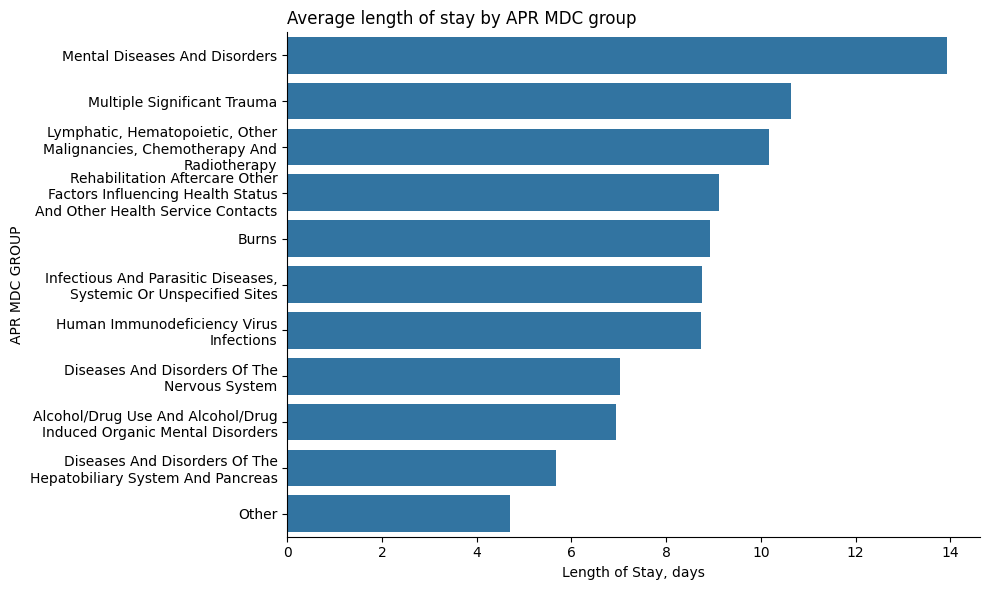

In [110]:
n_groups = 10 #summary_df.shape[0]
statistic_col = "avg_los"

top_groups = summary_df.sort_values(statistic_col, ascending=False).head(n_groups)[group_col]

df_temp = df.copy()

df_temp["apr_mdc_grouped"] = df_temp[group_col].where(
    df_temp[group_col].isin(top_groups),
    "OTHER"
)

df_plot = df_temp.groupby("apr_mdc_grouped").agg(
    avg_los = ('length_of_stay', "mean")
).sort_values(statistic_col, ascending=False).reset_index()


df_plot["apr_mdc_grouped"] = df_plot["apr_mdc_grouped"].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  "avg_los",
    y = "apr_mdc_grouped"
)

sns.despine()
plt.title("Average length of stay by APR MDC group", loc = "left")
plt.xlabel("Length of Stay, days")
plt.ylabel("APR MDC GROUP")
plt.tight_layout()
plt.show()

### Group Difference: APR DRG Description Total Costs, Total Charges, Length of Stay

In [111]:
#the frist 10 groups contain for 32% of instances
find_num_groups(get_number_of_instances(df, "apr_drg_description"), 32)

(10, 32.27892096322864)

In [112]:
group_col = "apr_drg_description"

summary_df = df.groupby(group_col)[[group_col, "total_costs", "total_charges", "length_of_stay"]].agg(
    number_of_instances = (group_col, "size"),
    total_cost = ("total_costs", "sum"),
    total_charge = ("total_charges", "sum"),
    total_los = ("length_of_stay", "sum"),
    avg_cost = ("total_costs", "mean"),
    avg_charge = ("total_charges", "mean"),
    avg_los = ("length_of_stay", "mean"),
    median_cost = ("total_costs", "median"),
    median_charge = ("total_charges", "median"),
    median_los = ("length_of_stay", "median")
).reset_index()

summary_df[group_col] = summary_df[group_col].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
)

In [113]:
summary_df[["number_of_instances", "avg_cost", "avg_charge", "avg_los"]].corr()

,number_of_instances,avg_cost,avg_charge,avg_los
number_of_instances,1.000000,-0.136710,-0.134038,-0.129077
avg_cost,-0.136710,1.000000,0.990596,0.849994
avg_charge,-0.134038,0.990596,1.000000,0.875800
avg_los,-0.129077,0.849994,0.875800,1.000000


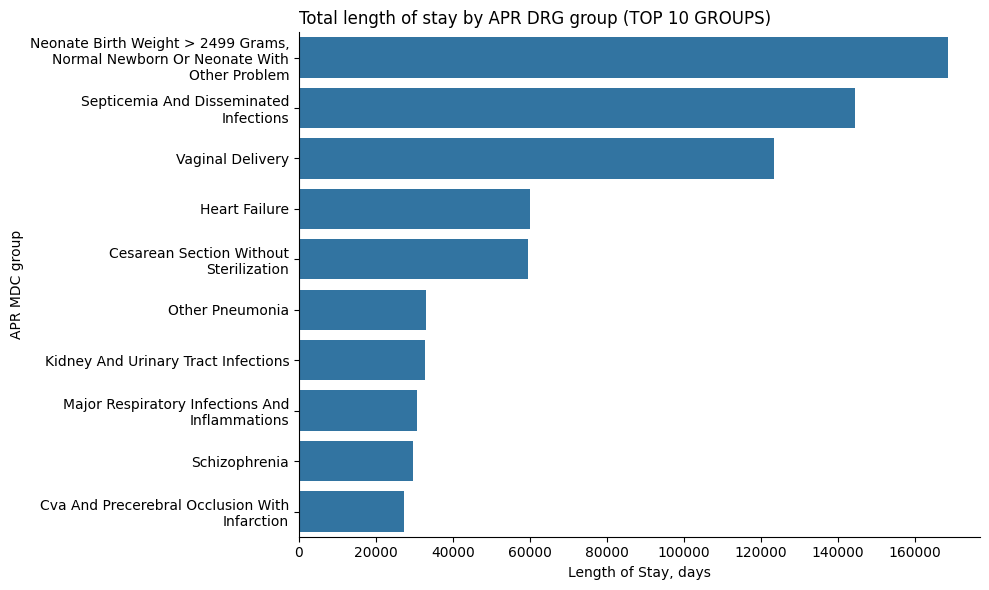

In [114]:
col = 'number_of_instances'

df_plot = summary_df[[group_col, col]].sort_values(col, ascending = False).head(10).reset_index(drop = False)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  col,
    y = group_col
)

sns.despine()
plt.title("Total length of stay by APR DRG group (TOP 10 GROUPS)", loc = "left")
plt.xlabel("Length of Stay, days")
plt.ylabel("APR MDC group")
plt.tight_layout()
plt.show()

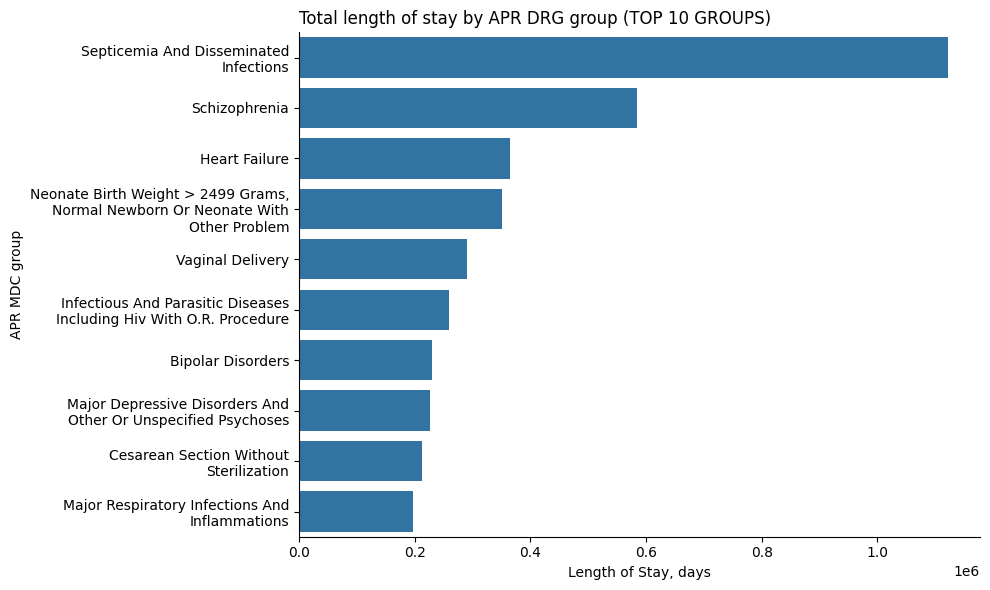

In [115]:
col = 'total_los'

df_plot = summary_df[[group_col, col]].sort_values(col, ascending = False).head(10).reset_index(drop = False)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  col,
    y = group_col
)

sns.despine()
plt.title("Total length of stay by APR DRG group (TOP 10 GROUPS)", loc = "left")
plt.xlabel("Length of Stay, days")
plt.ylabel("APR MDC group")
plt.tight_layout()
plt.show()

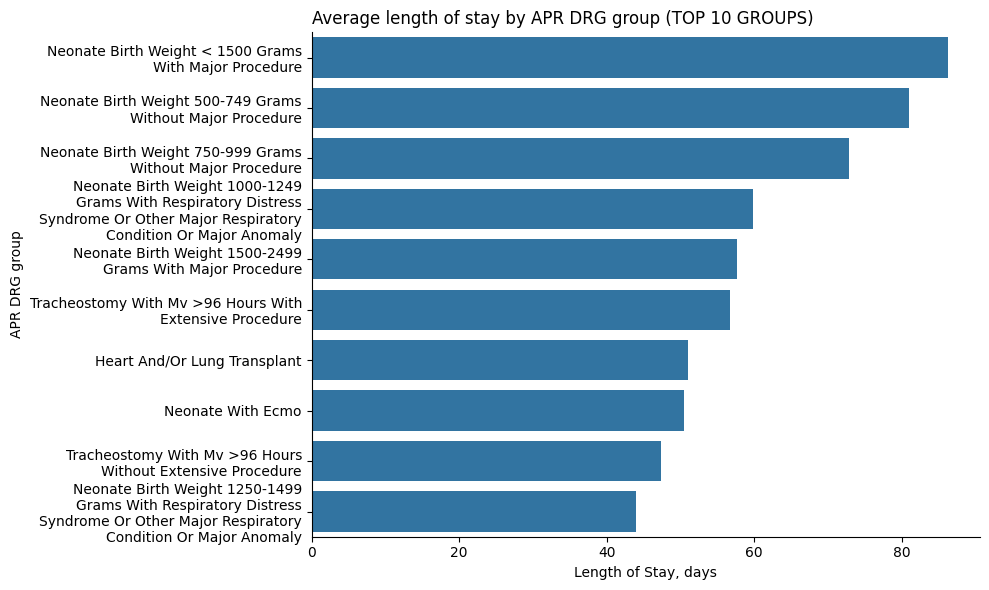

In [116]:
col = 'avg_los'

df_plot = summary_df[[group_col, col]].sort_values(col, ascending = False).head(10).reset_index(drop = False)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  col,
    y = group_col
)

sns.despine()
plt.title("Average length of stay by APR DRG group (TOP 10 GROUPS)", loc = "left")
plt.xlabel("Length of Stay, days")
plt.ylabel("APR DRG group")
plt.tight_layout()
plt.show()

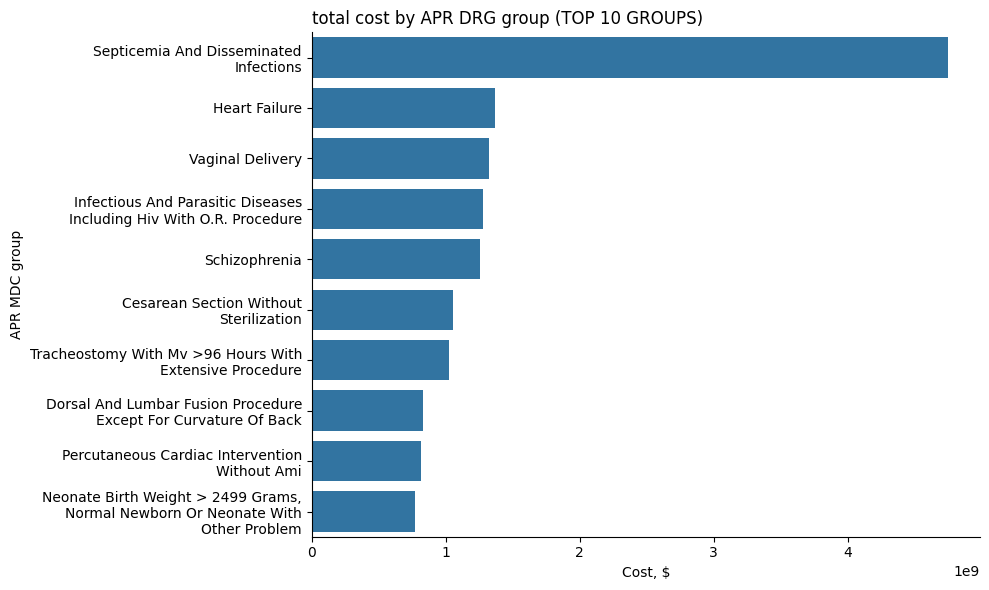

In [117]:
col = 'total_cost'

df_plot = summary_df[[group_col, col]].sort_values(col, ascending = False).head(10).reset_index(drop = False)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  col,
    y = group_col
)

sns.despine()
plt.title("total cost by APR DRG group (TOP 10 GROUPS)", loc = "left")
plt.xlabel("Cost, $")
plt.ylabel("APR MDC group")
plt.tight_layout()
plt.show()

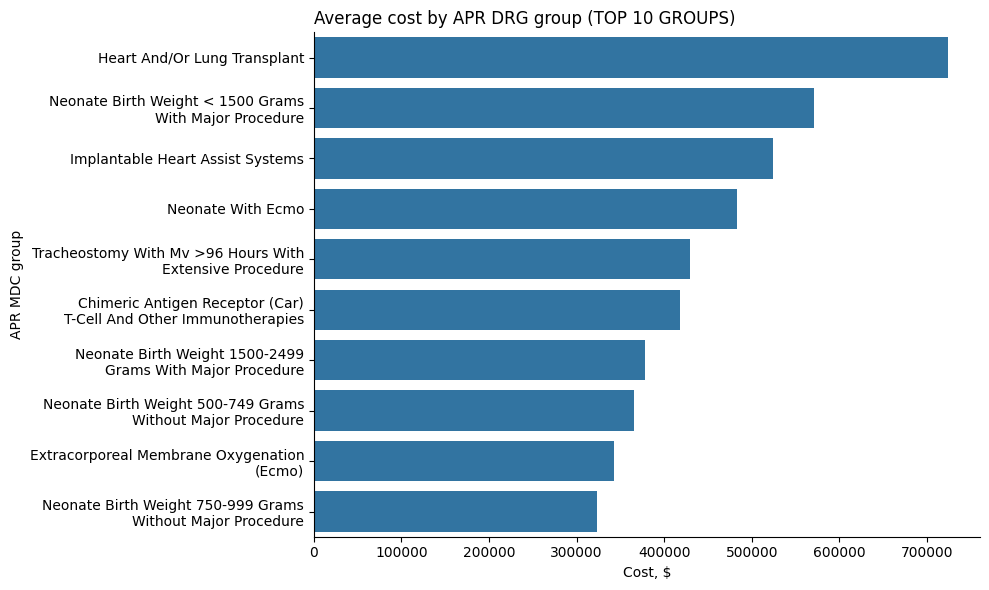

In [118]:
col = 'avg_cost'

df_plot = summary_df[[group_col, col]].sort_values(col, ascending = False).head(10).reset_index(drop = False)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = df_plot,
    x =  col,
    y = group_col
)

sns.despine()
plt.title("Average cost by APR DRG group (TOP 10 GROUPS)", loc = "left")
plt.xlabel("Cost, $")
plt.ylabel("APR MDC group")
plt.tight_layout()
plt.show()

### Group Difference: Emergency Department Indicator, Total Costs, Total Charges, Length of Stay, Petient Disposition, APR Severity of Illness

most of the difference in total cost appears to come from the much larger number of Y records, not from a dramatic difference in average cost per discharge

In [119]:
group_col = "emergency_department_indicator"

summary_df = df.groupby(group_col)[[group_col, "total_costs", "total_charges", "length_of_stay"]].agg(
    number_of_instances = (group_col, "size"),
    total_cost = ("total_costs", "sum"),
    total_charge = ("total_charges", "sum"),
    total_los = ("length_of_stay", "sum"),
    avg_cost = ("total_costs", "mean"),
    avg_charge = ("total_charges", "mean"),
    avg_los = ("length_of_stay", "mean"),
    median_cost = ("total_costs", "median"),
    median_charge = ("total_charges", "median"),
    median_los = ("length_of_stay", "median")
).reset_index()

In [120]:
summary_df

,emergency_department_indicator,number_of_instances,total_cost,total_charge,total_los,avg_cost,avg_charge,avg_los,median_cost,median_charge,median_los
0,N,819596,2.106663e+10,7.240051e+10,4132701,25703.673175,88336.824063,5.042364,12981.47,38543.80,2.0
1,Y,1377141,3.696366e+10,1.266797e+11,8630910,26840.868076,91987.478444,6.267267,14780.14,51669.72,4.0


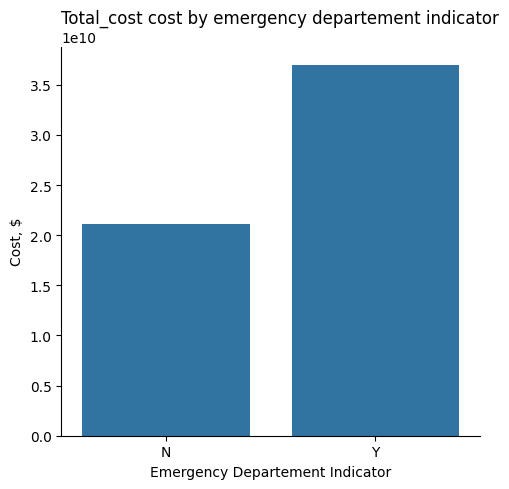

In [121]:
plt.figure(figsize = (5,5))

sns.barplot(
    data = summary_df,
    x = group_col,
    y = "total_cost"
)

sns.despine()
plt.title("Total_cost cost by emergency departement indicator", loc = "left")
plt.ylabel("Cost, $")
plt.xlabel("Emergency Departement Indicator")
plt.tight_layout()
plt.show()

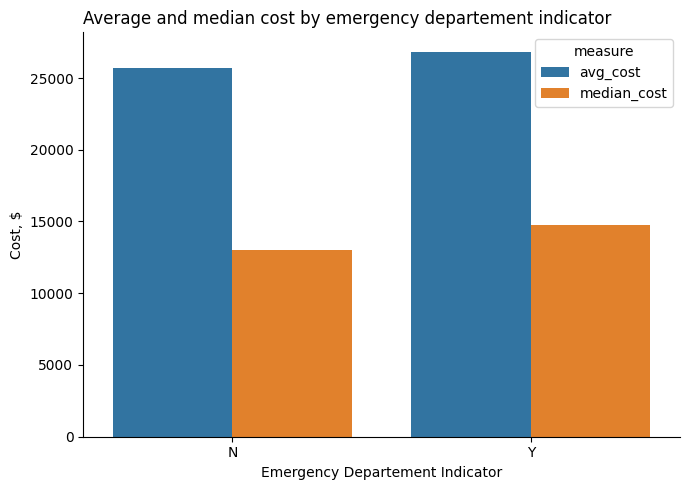

In [122]:
cols = ['avg_cost', 'median_cost']

df_plot = summary_df.melt(
    id_vars = group_col,
    value_vars = cols,
    var_name = "measure",
    value_name = "value"
)

plt.figure(figsize = (7,5))

sns.barplot(
    data = df_plot,
    x = group_col,
    y = "value",
    hue = "measure"
)

sns.despine()
plt.title("Average and median cost by emergency departement indicator", loc = "left")
plt.ylabel("Cost, $")
plt.xlabel("Emergency Departement Indicator")
plt.tight_layout()
plt.show()

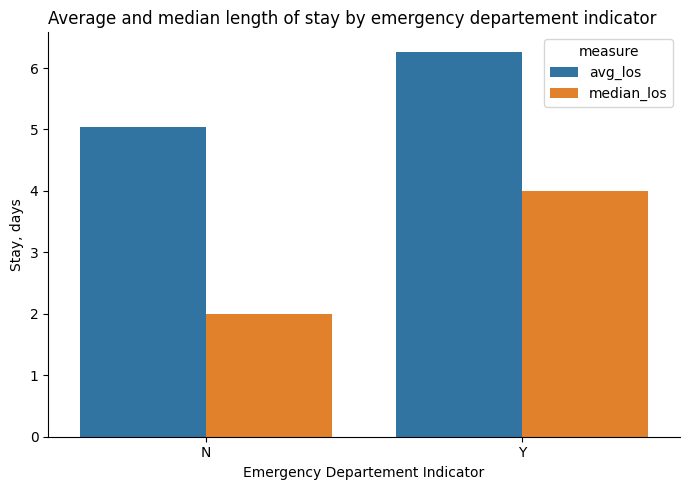

In [123]:
cols = ['avg_los', 'median_los']

df_plot = summary_df.melt(
    id_vars = group_col,
    value_vars = cols,
    var_name = "measure",
    value_name = "value"
)

plt.figure(figsize = (7,5))

sns.barplot(
    data = df_plot,
    x = group_col,
    y = "value",
    hue = "measure"
)

sns.despine()
plt.title("Average and median length of stay by emergency departement indicator", loc = "left")
plt.ylabel("Stay, days")
plt.xlabel("Emergency Departement Indicator")
plt.tight_layout()
plt.show()

In [124]:
summary_df

,emergency_department_indicator,number_of_instances,total_cost,total_charge,total_los,avg_cost,avg_charge,avg_los,median_cost,median_charge,median_los
0,N,819596,2.106663e+10,7.240051e+10,4132701,25703.673175,88336.824063,5.042364,12981.47,38543.80,2.0
1,Y,1377141,3.696366e+10,1.266797e+11,8630910,26840.868076,91987.478444,6.267267,14780.14,51669.72,4.0


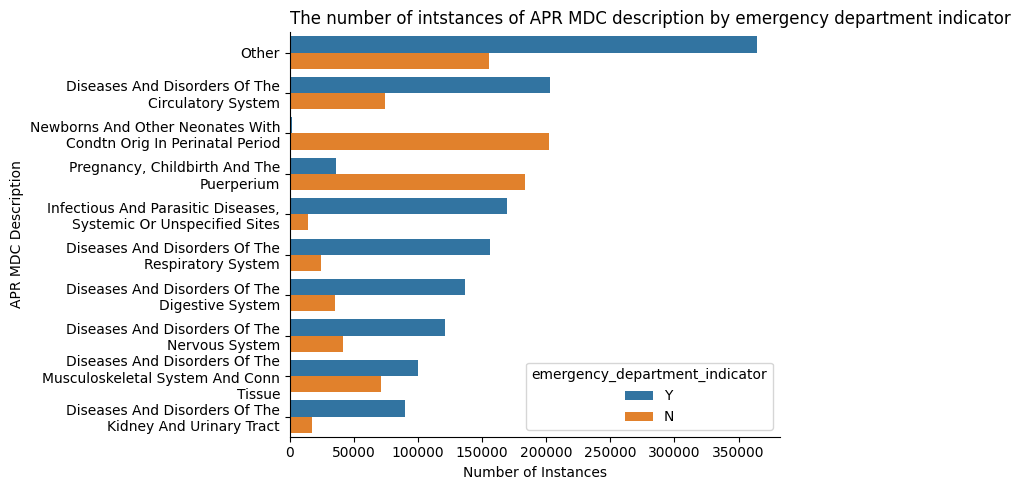

In [126]:
col1 = "apr_mdc_description"
col2 = "apr_mdc_grouped"
n_groups = 9

df_temp = df.copy()

top_groups = get_number_of_instances(df, col1).sort_values("number_of_instances", ascending = False).head(n_groups)[col1].tolist()

df_temp[col2] = df_temp[col1].where(
    df_temp[col1].isin(top_groups),
    "OTHER"
)

df_plot = df_temp.groupby([group_col, col2]).size().sort_values(ascending=False).reset_index(name = "count")

df_plot[col2] = df_plot[col2].apply(
      lambda x: textwrap.fill(str(x).title(), width=35)
)

plt.figure(figsize = (8,5))

sns.barplot(
    data = df_plot,
    x = "count",
    y = col2,
    hue = group_col
)

sns.despine()
plt.title("The number of intstances of APR MDC description by emergency department indicator", loc = "left")
plt.xlabel("Number of Instances")
plt.ylabel("APR MDC Description")
plt.tight_layout()
plt.show()

In [127]:
col = "number_of_instances"
p = (summary_df.loc[0, col] / summary_df[col].sum() * 100).round(2).item()

p, 100 - p

(37.31, 62.69)

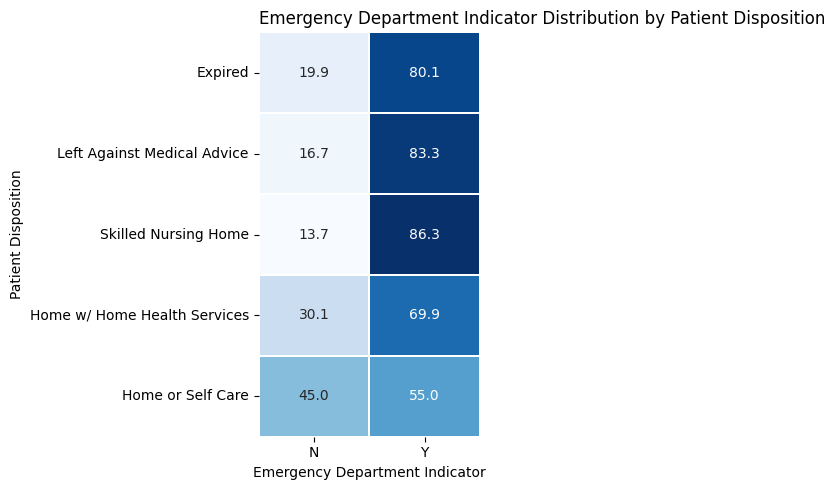

In [128]:
col = "patient_disposition"
pd_order = [
    "Expired",
    "Left Against Medical Advice",
    "Skilled Nursing Home",
    "Home w/ Home Health Services",
    "Home or Self Care",
    ]

mask = df[col].isin(pd_order)

ct =  pd.crosstab(
    df.loc[mask, col],
    df.loc[:, group_col],
) * 100

ct = ct.reindex(index = pd_order)

#index normalized
df_plot = ct.div(ct.sum(axis = 1), axis = 0) * 100

plt.figure(figsize = (5,5))

sns.heatmap(
    data = df_plot,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Emergency Department Indicator")
plt.ylabel("Patient Disposition")
plt.title("Emergency Department Indicator Distribution by Patient Disposition", loc = "left")
plt.tight_layout()
plt.show()

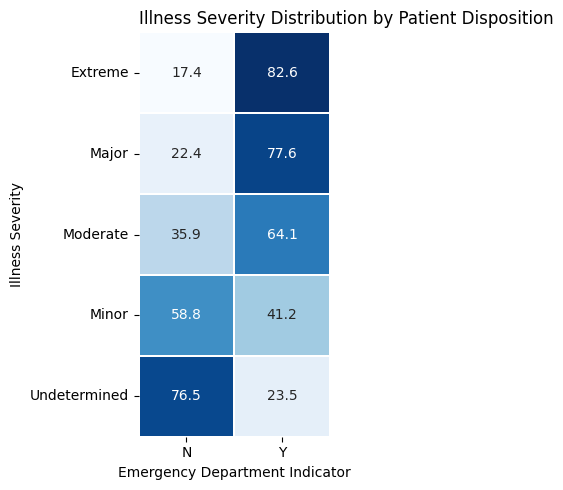

In [129]:
col = "apr_severity_of_illness"
si_order = [
    "Extreme",
    "Major",
    "Moderate",
    "Minor",
    "Undetermined"
    ]

ct =  pd.crosstab(
    df.loc[:, col],
    df.loc[:, group_col],
) * 100

ct = ct.reindex(index = si_order)

#index normalized
df_plot = ct.div(ct.sum(axis = 1), axis = 0) * 100

plt.figure(figsize = (3.5,5))

sns.heatmap(
    data = df_plot,
    fmt = ".1f",
    annot = True,
    cmap = "Blues",
    linewidths = 0.01,
    cbar = False
)

plt.yticks(rotation = 0)
plt.xlabel("Emergency Department Indicator")
plt.ylabel("Illness Severity")
plt.title("Illness Severity Distribution by Patient Disposition", loc = "left")
plt.tight_layout()
plt.show()

# Test Area

In [ ]:
#